# Astrometric concordance after the v10 latent position head

How well do Rubin and Euclid NISP each align to Euclid VIS after our
per-object latent position head runs, and what is left over for a smooth concordance field
to correct? This notebook walks through the answer on ECDFS (790 tiles), using the active
anchor cache printed in the setup cell. The comparison section below also checks the classical
and CenterNet anchor caches side by side when both are present.

**What you'll see**

1. **Before / after summary.** Per-band bar chart, radial histograms and
   decomposed vector statistics comparing raw WCS, a smooth PINN field
   on raw anchors, the head correction, and a smooth PINN field on the
   head residual. Establishes the headline numbers for the active cache.
2. **Anchor-source comparison.** Classical peak-finder anchors vs CenterNet anchors,
   separating detector/catalog effects from latent-head effects.
3. **Spatial field maps.** 9 bands x 4 sky-binned columns: raw-anchor
   offsets, PINN raw, head-residual offsets, PINN after head. Tests
   whether the head removes coherent spatial structure anchor-by-anchor.
4. **Anchor population.** Per-band SNR distributions, spatial density at
   absolute SNR cuts, and bright-anchor counts per arcmin² resolution element.
   Characterizes how much a classical bright-only concordance workflow has to work with.
5. **Anchor-pool PINN refits.** Refit the PINN on an explicit
   classical slice (`SNR >= 30`) plus `bright`, `mid` and `faint`
   per-band terciles, for both raw anchors and head-residual anchors.
   This keeps the classical bright-anchor question separate from
   tercile-based SNR diagnostics.
6. **Sparse-field recovery.** Can non-classical sources (`SNR < 30`) reproduce
   the smooth field that classical bright anchors (`SNR >= 30`) pin down?
   And does the head's per-source prediction act as a dense sampling of that
   same smooth field?

**Scope.** Every figure and table below uses VIS as the reference and compares the 9 non-VIS bands against it: Rubin ugrizy to VIS and NISP YJH to VIS. Rubin and NISP sit on different native pixel grids (0.2"/px and 0.1"/px) and have different PSFs, so their centroid-noise floors differ; SNR-dependent slices and weights are therefore defined or normalized per band. When the active cache is CenterNet-selected, `classical` below means an `SNR >= 30` slice inside that selected catalogue, not a classical-detector baseline.

**Why this matters.** ECDFS is anchor-rich, so a classical bright-only
concordance fit is already a few-mas measurement. In sparser fields
(shallow footprints, high galactic latitude gaps, few unsaturated stars),
the bright-anchor count per arcmin² resolution element can drop sharply.
If the latent head can convert faint and mid-SNR galaxies into usable
anchors, we can measure concordance where bright stars are not available.


## ⚠ 2026-06-10 audit note — read before quoting results

1. **Leakage**: the eval archive covers all 790 tiles (~85% trained-on), and tile-level splits do not hold out sky — 50% tile overlap means ~95% of seed-42 val-tile sources have train-tile duplicates. On truly-unseen sources at fixed SNR the head's gain is ~40-50% residual reduction, not the headline 75-77% (e.g. 55 vs 12 mas at SNR 7-10; converges above SNR≈30). Publication numbers need a spatially disjoint split.
2. **The trust diagnostics in this notebook did not pass their own criteria** in the current run: the shuffled-null test gives real/null ≈ 1.3× median (one slice at 0.4×) — a marginal detection by the notebook's stated standard; the sklearn GP cross-check fails calibration (length scale at lower bound, z-score std 1.71, 20 mas disagreement with PINN); the sparse-field recovery test gives 24 mas vector RMS where the success criterion was "a few mas". None of these is flagged in the result cells below.
3. **PINN reproducibility floor**: two PINN fits on identical anchors differ by ~5 mas RMS unsmoothed (r≈0.69). Field structure below that, or comparisons between single fits, are solver noise. The 50-mas dedup also starves sparse bands (z anchors 3.2× fewer → z field inflates ~2×).
4. The headline 54.1 → 13.2 mas dedup medians and the per-band tables are arithmetically correct and match DOCUMENTATION.md; the caveats above are about interpretation, not computation.
---
**RESOLUTION (2026-06-11).** The patch-disjoint retrain (`latent_position_v10_patchval25`, patch 25 fully held out) settled point 1: **no leakage inflation** — the disjoint head matches production on never-seen sky in every band/SNR bin (pooled median 10.7 vs 11.0 mas on identical border-excluded sources; `_nb09_outputs/patch25_verdict.txt`). The interim "val-pure 3-4×" estimate was selection bias.

However, the **synthetic-injection truth test** (`_nb09_outputs/injection_truth_test.py`) showed the residual-vs-label metric in this notebook measures *emulation of the classical centroid* at the faint end (label noise ~70 mas at SNR 5-7 vs 13 mas residual — the noise rides on both the head's input features and its query coordinates). True position error vs injected truth: head ≈ VIS-anchor floor + 2-4 mas (Rubin SNR 5: head 18.5 mas vs classical band 47 mas) — the head is a genuine ~2.5× faint-end gain, working as a VIS-localization transfer. Joint 10-band canonical centroiding was then validated 2.4-2.5× better than the VIS-only floor at all SNR (6.7 mas at SNR 5; `joint_centroid_truth_results.json`); a retrain on joint labels is in progress. Summary figure: `docs/figures/astrometry_truth_vs_snr.png`.


In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
from IPython.display import display
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import map_coordinates
from scipy.stats import binned_statistic_2d

plt.rcParams["figure.dpi"] = 120
plt.rcParams["image.origin"] = "lower"


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / "models").exists() and (cand / "io").exists():
            return cand
    return start


ROOT = find_repo_root()
FIGS = ROOT / 'docs' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)
MODELS = ROOT / "models"
if str(MODELS) not in sys.path:
    sys.path.insert(0, str(MODELS))

from astrometry2.pinn_field_solver import evaluate_pinn_mesh, fit_pinn_field
from astrometry2.fit_direct_pinn import sky_to_tangent_plane

# Active v10 astrometry run. Use JAISP_ASTROMETRY_RUN=epsf_centroid to inspect
# the ePSF-centroid ablation instead of the Gaussian-centroid control.
import os as _os
RUN_KEY = _os.environ.get("JAISP_ASTROMETRY_RUN", "no_psf")
RUNS = {
    "no_psf": {
        "ckpt": ROOT / "models" / "checkpoints" / "latent_position_v10_no_psf",
        "anchors": "anchors_centernet_v10_dedup.npz",
        "label": "v10 Gaussian-centroid control",
    },
    "epsf_centroid": {
        "ckpt": ROOT / "models" / "checkpoints" / "latent_position_v10_epsf_centroid",
        "anchors": "anchors_centernet_v10_epsf_dedup.npz",
        "label": "v10 ePSF-centroid ablation",
    },
}
if RUN_KEY not in RUNS:
    raise ValueError(f"Unknown JAISP_ASTROMETRY_RUN={RUN_KEY!r}; choose one of {sorted(RUNS)}")
ACTIVE_RUN = RUNS[RUN_KEY]
CKPT = ACTIVE_RUN["ckpt"]
OUT_DIR = ROOT / "io"

# Anchor cache. Override with ANCHORS_FILE=... after exporting eval anchors.
_default_anchors = ACTIVE_RUN["anchors"]
ANCHORS_FILE_NAME = _os.environ.get("ANCHORS_FILE", _default_anchors)
ANCHORS_PATH = CKPT / ANCHORS_FILE_NAME


def anchor_cache_source(file_name: str) -> str:
    name = Path(file_name).name.lower()
    if "centernet" in name:
        return "centernet"
    if name == "anchors_v10_classical.npz" or "classical" in name:
        return "classical"
    return "custom"


ACTIVE_ANCHOR_SOURCE = anchor_cache_source(ANCHORS_FILE_NAME)
ANCHOR_SOURCE_FILES = {
    "active": ANCHORS_PATH,
    "v10_gaussian": ROOT / "models" / "checkpoints" / "latent_position_v10_no_psf" / "anchors_centernet_v10_dedup.npz",
    "v10_epsf": ROOT / "models" / "checkpoints" / "latent_position_v10_epsf_centroid" / "anchors_centernet_v10_epsf_dedup.npz",
    "classical": CKPT / "anchors_v10_classical.npz",
}
FITS_PINN_RAW = CKPT / "concordance_pinn_centernet_v10_raw.fits"
FITS_PINN_HEAD = CKPT / "concordance_pinn_centernet_v10_head_resid.fits"

for label, p in [
    (f"Anchors ({ANCHORS_FILE_NAME})", ANCHORS_PATH),
    ("PINN raw FITS", FITS_PINN_RAW),
    ("PINN head-resid FITS", FITS_PINN_HEAD),
]:
    rel = p.relative_to(ROOT) if p.exists() else p
    print(f"{label:22s}: {rel}  {'OK' if p.exists() else 'MISSING'}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"active anchor source : {ACTIVE_ANCHOR_SOURCE}")
print(f"torch device          : {DEVICE}")

# Band order and short / FITS-extension / anchors-key mapping.
RUBIN_BANDS = ["u", "g", "r", "i", "z", "y"]
NISP_BANDS = ["nisp_Y", "nisp_J", "nisp_H"]
ALL_BANDS = RUBIN_BANDS + NISP_BANDS

# Band index for the PINN chromatic embedding (matches dataset.BAND_TO_IDX).
BAND_TO_IDX = {
    "u": 0, "g": 1, "r": 2, "i": 3, "z": 4, "y": 5,
    "nisp_Y": 6, "nisp_J": 7, "nisp_H": 8,
}
N_BANDS = 9

# Shared SNR / weighting conventions used throughout the notebook.
SNR_CLASSICAL = 30.0       # absolute bright-anchor cut for classical concordance
SNR_MID_ABS = 10.0         # descriptive absolute cut for faint / mid / bright density maps
SNR_WEIGHT_FLOOR = 3.0     # avoid pathological inverse-variance weights at very low SNR
SNR_WEIGHT_CAP = 150.0     # cap saturated or suspiciously extreme SNR leverage
SNR_WEIGHT_MIN = 0.05
SNR_WEIGHT_MAX = 25.0


def display_band(b: str) -> str:
    return b.replace("nisp_", "NISP ")


def fits_ext(b: str) -> str:
    return b.replace("nisp_", "NISP_") if b.startswith("nisp_") else b.upper()


def mag_mas(offset_arcsec: np.ndarray) -> np.ndarray:
    return np.hypot(offset_arcsec[:, 0], offset_arcsec[:, 1]) * 1000.0


def med_mas(offset_arcsec: np.ndarray) -> float:
    return float(np.nanmedian(mag_mas(offset_arcsec)))


def p68_mas(offset_arcsec: np.ndarray) -> float:
    return float(np.nanpercentile(mag_mas(offset_arcsec), 68.0))


def mad_sigma(x: np.ndarray) -> float:
    return 1.4826 * float(np.nanmedian(np.abs(x - np.nanmedian(x))))


def vector_stats(arr_arcsec: np.ndarray) -> dict:
    arr_mas = np.asarray(arr_arcsec) * 1000.0
    mag = np.hypot(arr_mas[:, 0], arr_mas[:, 1])
    sys_ = np.hypot(np.nanmedian(arr_mas[:, 0]), np.nanmedian(arr_mas[:, 1]))
    return {
        "sys": float(sys_),
        "med": float(np.nanmedian(mag)),
        "p68": float(np.nanpercentile(mag, 68.0)),
        "mad_ra": mad_sigma(arr_mas[:, 0]),
        "mad_de": mad_sigma(arr_mas[:, 1]),
    }


Anchors (anchors_centernet_v10_dedup.npz): models/checkpoints/latent_position_v10_no_psf/anchors_centernet_v10_dedup.npz  OK
PINN raw FITS         : models/checkpoints/latent_position_v10_no_psf/concordance_pinn_centernet_v10_raw.fits  OK
PINN head-resid FITS  : models/checkpoints/latent_position_v10_no_psf/concordance_pinn_centernet_v10_head_resid.fits  OK
active anchor source : centernet
torch device          : cuda


## Part 1 -- Before / after summary

Load the anchor cache, sample the precomputed PINN fields at each source
position, and produce the headline bar chart, radial histograms and
decomposed statistics. Samples outside the FITS field are masked rather
than nearest-clamped. Every number is in milliarcseconds.


In [2]:
anchors = np.load(ANCHORS_PATH, allow_pickle=True)
print(f"{ANCHORS_FILE_NAME} keys: {len(anchors.files)}")
for k in sorted(anchors.files)[:6]:
    print(f"  {k}: shape={anchors[k].shape} dtype={anchors[k].dtype}")
print("  ...")


def sample_field_at_sources(fits_path: Path, band: str, ra, dec) -> np.ndarray | None:
    ext = fits_ext(band)
    with fits.open(fits_path) as hdul:
        try:
            dra_hdu = hdul[f"{ext}.DRA"]
            dde_hdu = hdul[f"{ext}.DDE"]
        except KeyError:
            return None
        dra_map = np.asarray(dra_hdu.data, dtype=np.float64)
        dde_map = np.asarray(dde_hdu.data, dtype=np.float64)
        w = WCS(dra_hdu.header, naxis=2)
    ra_arr = np.asarray(ra)
    dec_arr = np.asarray(dec)
    px, py = w.wcs_world2pix(ra_arr, dec_arr, 0)
    out = np.full((ra_arr.size, 2), np.nan, dtype=np.float32)
    inside = (
        np.isfinite(px) & np.isfinite(py)
        & (px >= 0) & (py >= 0)
        & (px <= dra_map.shape[1] - 1)
        & (py <= dra_map.shape[0] - 1)
    )
    if inside.any():
        coords = np.stack([py[inside], px[inside]], axis=0)
        out[inside, 0] = map_coordinates(dra_map, coords, order=1, mode="nearest")
        out[inside, 1] = map_coordinates(dde_map, coords, order=1, mode="nearest")
    return out


data = {}
header_fmt = (
    f'{"Band":>8} {"N":>8}  {"Raw":>8} {"Raw+PINN":>9} {"Head":>8} '
    f'{"Head+PINN":>10}  {"|Fraw|":>8} {"|Fhead|":>8}'
)
print("\n" + header_fmt)
print("-" * 88)
for band in ALL_BANDS:
    if f"{band}_raw" not in anchors or f"{band}_head_resid" not in anchors:
        print(f"{display_band(band):>8}  missing in anchors, skipping")
        continue
    ra = anchors[f"{band}_ra"]
    dec = anchors[f"{band}_dec"]
    raw = anchors[f"{band}_raw"].astype(np.float32)
    head = anchors[f"{band}_head_resid"].astype(np.float32)
    snr = (anchors[f"{band}_snr"]
           if f"{band}_snr" in anchors.files else np.full(len(raw), np.nan, dtype=np.float32))
    tiles = (anchors[f"{band}_tiles"]
             if f"{band}_tiles" in anchors.files else np.full(len(raw), "", dtype=object))
    raw_field = sample_field_at_sources(FITS_PINN_RAW, band, ra, dec)
    head_field = sample_field_at_sources(FITS_PINN_HEAD, band, ra, dec)
    raw_pinn = (raw - raw_field) if raw_field is not None else None
    head_pinn = (head - head_field) if head_field is not None else None
    # Also compute what the head predicted per source (= raw - head_resid).
    head_pred = (raw - head).astype(np.float32)
    data[band] = {
        "ra": ra, "dec": dec,
        "raw": raw, "head": head, "head_pred": head_pred, "snr": snr, "tiles": tiles,
        "raw_field": raw_field, "head_field": head_field,
        "raw_pinn": raw_pinn, "head_pinn": head_pinn,
        "n": len(raw),
    }
    print(
        f'{display_band(band):>8} {len(raw):8d}  '
        f'{med_mas(raw):8.1f} '
        f'{med_mas(raw_pinn) if raw_pinn is not None else np.nan:9.1f} '
        f'{med_mas(head):8.1f} '
        f'{med_mas(head_pinn) if head_pinn is not None else np.nan:10.1f}  '
        f'{med_mas(raw_field) if raw_field is not None else np.nan:8.1f} '
        f'{med_mas(head_field) if head_field is not None else np.nan:8.1f}'
    )

bands_present = [b for b in ALL_BANDS if b in data]
print(f"\n{len(bands_present)} bands loaded")


anchors_centernet_v10_dedup.npz keys: 54
  g_dec: shape=(19686,) dtype=float32
  g_head_resid: shape=(19686, 2) dtype=float32
  g_ra: shape=(19686,) dtype=float32
  g_raw: shape=(19686, 2) dtype=float32
  g_snr: shape=(19686,) dtype=float32
  g_tiles: shape=(19686,) dtype=<U64
  ...

    Band        N       Raw  Raw+PINN     Head  Head+PINN    |Fraw|  |Fhead|
----------------------------------------------------------------------------------------
       u     6898     130.3     129.9     43.9       43.7       9.8      1.6
       g    19686      63.2      63.0     15.0       15.0       4.7      0.7
       r    22255      53.2      53.0     12.9       13.0       4.5      1.1
       i    20270      50.6      50.3     13.4       13.4       5.4      0.9
       z    15418      58.4      58.8     16.2       16.2       5.8      1.1
       y     7694      96.5      96.2     27.1       27.1       6.4      1.7
  NISP Y    33932      47.9      47.5     11.2       11.2       6.9      1.1
  NISP J  

### Optional SNR-windowed before/after stats

Use this cell when you want the per-band medians/RMS on a controlled SNR range, for example `5 < S/N < 50`, rather than on the full anchor catalogue. This does not change the rest of the notebook; it is a side table for direct comparison.

In [ ]:
# Defaults to 5 < S/N < 50. Override from the shell with, e.g.
# NB08_SNR_MIN=5 NB08_SNR_MAX=50 jupyter notebook
SNR_WINDOW_MIN = float(_os.environ.get("NB08_SNR_MIN", "10"))
_snr_max_text = _os.environ.get("NB08_SNR_MAX", "50").strip().lower()
SNR_WINDOW_MAX = None if _snr_max_text in {"", "none", "inf", "infinity"} else float(_snr_max_text)


def snr_window_mask(d, snr_min=SNR_WINDOW_MIN, snr_max=SNR_WINDOW_MAX):
    snr = np.asarray(d["snr"], dtype=np.float64)
    mask = np.isfinite(snr)
    if snr_min is not None:
        mask &= snr > snr_min
    if snr_max is not None:
        mask &= snr < snr_max
    return mask


def radial_stats_mas(arr_arcsec, mask):
    if arr_arcsec is None:
        return np.nan, np.nan
    arr = np.asarray(arr_arcsec)
    m = np.asarray(mask, dtype=bool) & np.isfinite(arr).all(axis=1)
    if not m.any():
        return np.nan, np.nan
    r = mag_mas(arr[m])
    r = r[np.isfinite(r)]
    if r.size == 0:
        return np.nan, np.nan
    return float(np.nanmedian(r)), float(np.sqrt(np.nanmean(r ** 2)))


def fmt_snr_window():
    upper = "inf" if SNR_WINDOW_MAX is None else f"{SNR_WINDOW_MAX:g}"
    return f"{SNR_WINDOW_MIN:g} < S/N < {upper}"


rows = []
stage_arrays = {"raw": [], "raw_pinn": [], "head": [], "head_pinn": []}
snr_all = []
for band in bands_present:
    d = data[band]
    sel = snr_window_mask(d)
    sel &= np.isfinite(d["raw"]).all(axis=1) & np.isfinite(d["head"]).all(axis=1)
    snr_sel = np.asarray(d["snr"], dtype=np.float64)[sel]
    raw_med, raw_rms = radial_stats_mas(d["raw"], sel)
    raw_pinn_med, raw_pinn_rms = radial_stats_mas(d["raw_pinn"], sel)
    head_med, head_rms = radial_stats_mas(d["head"], sel)
    head_pinn_med, head_pinn_rms = radial_stats_mas(d["head_pinn"], sel)
    rows.append((
        display_band(band), int(sel.sum()), 100.0 * float(sel.sum()) / max(int(d["n"]), 1),
        float(np.nanmedian(snr_sel)) if snr_sel.size else np.nan,
        raw_med, raw_rms, raw_pinn_med, raw_pinn_rms,
        head_med, head_rms, head_pinn_med, head_pinn_rms,
    ))
    snr_all.append(snr_sel)
    for key in stage_arrays:
        arr = d[key]
        if arr is not None and sel.any():
            arr = np.asarray(arr)
            m = sel & np.isfinite(arr).all(axis=1)
            if m.any():
                stage_arrays[key].append(arr[m])

window_tab = Table(
    rows=rows,
    names=[
        "band", "N", "kept_pct", "snr_med",
        "raw_med", "raw_rms", "raw_pinn_med", "raw_pinn_rms",
        "head_med", "head_rms", "head_pinn_med", "head_pinn_rms",
    ],
)
for col in window_tab.colnames:
    if col not in {"band", "N"}:
        window_tab[col].format = ".2f"

print(f"SNR-windowed residual stats: {fmt_snr_window()}  [{ACTIVE_RUN['label']}; {ANCHORS_FILE_NAME}]")
display(window_tab)

overall = []
snr_concat = np.concatenate([x for x in snr_all if len(x)]) if any(len(x) for x in snr_all) else np.array([])
for key, arrs in stage_arrays.items():
    if not arrs:
        continue
    arr = np.concatenate(arrs, axis=0)
    med, rms = radial_stats_mas(arr, np.ones(len(arr), dtype=bool))
    overall.append((key, len(arr), med, rms))

overall_tab = Table(rows=overall, names=["stage", "N", "median_mas", "rms_mas"])
for col in ["median_mas", "rms_mas"]:
    overall_tab[col].format = ".2f"
print(f"Overall across bands: N={sum(r[1] for r in overall if r[0] == 'raw'):,}, "
      f"median S/N={np.nanmedian(snr_concat):.2f}" if snr_concat.size else "Overall across bands: no anchors in window")
display(overall_tab)


SNR-windowed residual stats: 10 < S/N < 50  [v10 Gaussian-centroid control; anchors_centernet_v10_dedup.npz]


band,N,kept_pct,snr_med,raw_med,raw_rms,raw_pinn_med,raw_pinn_rms,head_med,head_rms,head_pinn_med,head_pinn_rms
str6,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
u,3776,54.74,13.69,133.70,136.28,133.79,136.24,44.77,69.65,44.60,69.66
g,7718,39.21,14.22,55.72,90.49,55.40,90.35,15.70,50.59,15.74,50.60
r,9209,41.38,14.90,42.09,80.64,41.79,80.54,13.04,47.04,13.06,47.03
i,8750,43.17,15.09,41.14,82.77,41.48,82.69,13.40,47.32,13.43,47.31
z,7150,46.37,14.77,52.84,95.22,53.57,95.44,16.78,51.99,16.73,51.97
y,4091,53.17,14.36,108.83,120.80,109.58,120.69,30.92,62.81,30.92,62.82
NISP Y,13923,41.03,15.37,28.29,50.37,27.62,49.75,7.89,28.97,7.90,28.94
NISP J,17196,44.82,15.62,30.77,55.77,29.95,55.11,8.40,33.34,8.42,33.29
NISP H,17411,46.52,15.91,32.04,59.94,31.33,59.41,8.82,36.52,8.81,36.47


Overall across bands: N=89,224, median S/N=15.11


stage,N,median_mas,rms_mas
str9,int64,float64,float64
raw,89224,37.73,77.00
raw_pinn,89219,37.22,76.75
head,89224,11.02,43.33
head_pinn,89218,11.05,43.31


In [ ]:
# Bar chart: Raw vs Raw+PINN vs Head vs Head+PINN.
x = np.arange(len(bands_present))
width = 0.19
series = [
    ("Raw WCS", "raw", "#c84b4b"),
    ("Raw + PINN field", "raw_pinn", "#d18b20"),
    ("Latent head", "head", "#3f7fbf"),
    ("Head + residual PINN", "head_pinn", "#3d9b63"),
]
values = {
    key: [med_mas(data[b][key]) if data[b][key] is not None else np.nan for b in bands_present]
    for _, key, _ in series
}

fig, ax = plt.subplots(figsize=(13, 5.6))
for i, (label, key, color) in enumerate(series):
    xpos = x + (i - 1.5) * width
    bars = ax.bar(xpos, values[key], width, label=label, color=color, alpha=0.86)
    for bar, val in zip(bars, values[key]):
        if not np.isfinite(val):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.0,
            f"{val:.0f}",
            ha="center", va="bottom", fontsize=7,
        )
ax.set_xticks(x)
ax.set_xticklabels([display_band(b) for b in bands_present], fontsize=9)
ax.set_ylabel("Median |offset| [mas]", fontsize=11)
ax.set_title("Astrometric offset vs Euclid VIS: before and after correction")
ax.legend(fontsize=8.5, ncol=2, loc="upper right")
ax.grid(axis="y", alpha=0.28)
ax.set_ylim(0, max(values["raw"]) * 1.22)
# CAVEAT pinned onto the figure itself (the saved PNG can be lifted out of context):
# the faint-end 'Latent head' reduction is largely CENTROID EMULATION, not added precision.
fig.text(
    0.5, -0.02,
    "Caveat: the 'Latent head' median reduction below SNR~15 is largely centroid emulation (label noise rides on the head's query coords),\n"
    "NOT added astrometric precision. Injection truth test: head =~ VIS-floor + 2-4 mas, with a ~17-18 mas faint-end ceiling. The precision\n"
    "position instrument is the classical joint 10-band fitter (6.7 mas @ SNR 5; see nb14). Read the top-of-notebook audit note before quoting.",
    ha="center", va="top", fontsize=7.5, color="#7a2b2b", style="italic", wrap=True,
)
plt.tight_layout()
plt.savefig(FIGS / "astrometry_before_after.png", dpi=220, bbox_inches="tight")
plt.show()

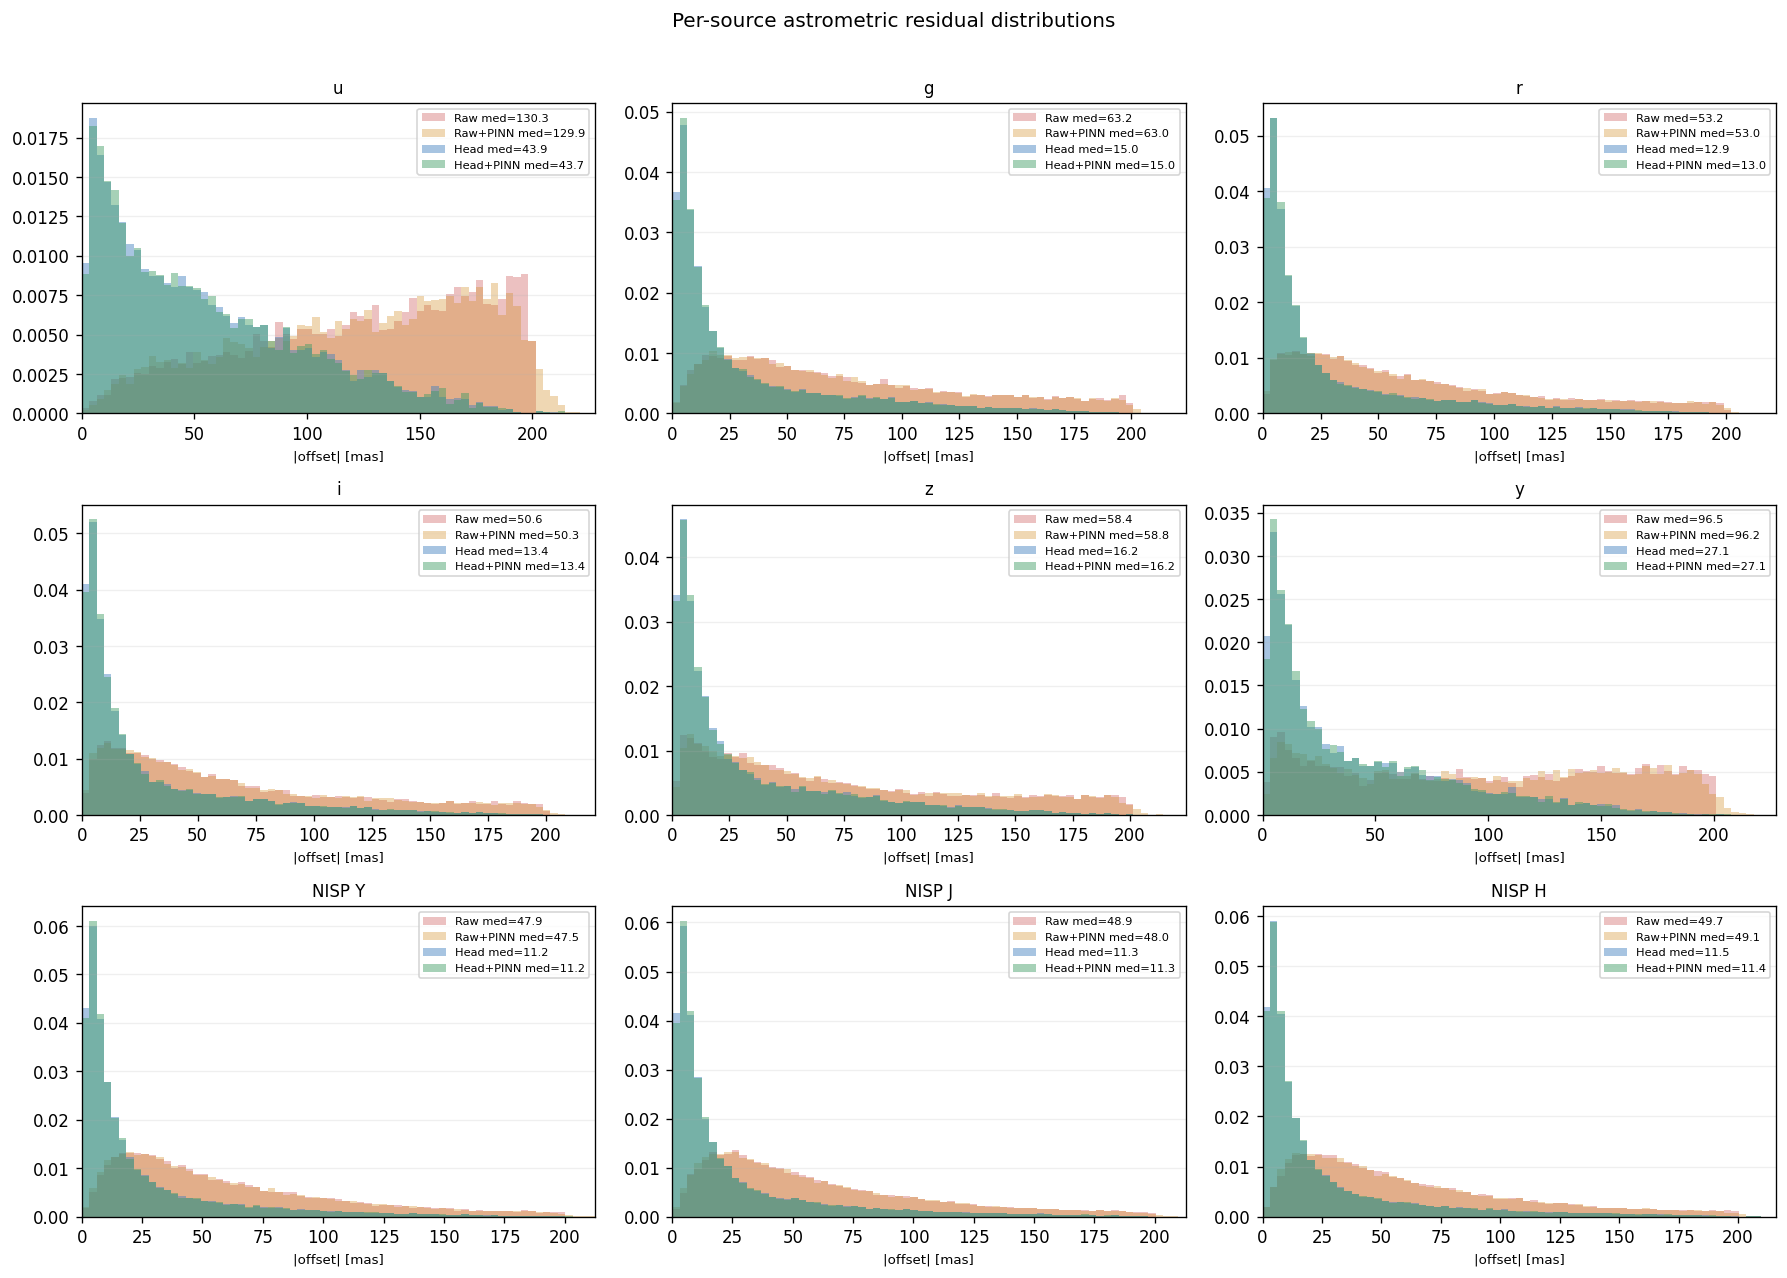

In [4]:
# Per-band radial histograms.
fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes_flat = axes.ravel()
for idx, band in enumerate(bands_present):
    ax = axes_flat[idx]
    d = data[band]
    raw_mag = mag_mas(d["raw"])
    head_mag = mag_mas(d["head"])
    raw_pinn_mag = mag_mas(d["raw_pinn"]) if d["raw_pinn"] is not None else None
    head_pinn_mag = mag_mas(d["head_pinn"]) if d["head_pinn"] is not None else None
    finite_ref = raw_mag[np.isfinite(raw_mag)]
    xlim = float(np.nanpercentile(finite_ref, 98.5)) if finite_ref.size else 100.0
    xlim = max(50.0, min(240.0, xlim * 1.15))
    bins = np.linspace(0, xlim, 70)
    ax.hist(raw_mag, bins=bins, alpha=0.34, color="#c84b4b", density=True,
            label=f"Raw med={np.nanmedian(raw_mag):.1f}")
    if raw_pinn_mag is not None:
        ax.hist(raw_pinn_mag, bins=bins, alpha=0.34, color="#d18b20", density=True,
                label=f"Raw+PINN med={np.nanmedian(raw_pinn_mag):.1f}")
    ax.hist(head_mag, bins=bins, alpha=0.46, color="#3f7fbf", density=True,
            label=f"Head med={np.nanmedian(head_mag):.1f}")
    if head_pinn_mag is not None:
        ax.hist(head_pinn_mag, bins=bins, alpha=0.46, color="#3d9b63", density=True,
                label=f"Head+PINN med={np.nanmedian(head_pinn_mag):.1f}")
    ax.set_title(display_band(band), fontsize=10)
    ax.set_xlabel("|offset| [mas]", fontsize=8)
    ax.set_xlim(0, xlim)
    ax.legend(fontsize=6.8)
    ax.grid(axis="y", alpha=0.2)
for ax in axes_flat[len(bands_present):]:
    ax.axis("off")
plt.suptitle("Per-source astrometric residual distributions", y=1.01)
plt.tight_layout()
plt.show()


In [5]:
# Decomposed statistics table: |sys|, med, p68, MADxy per stage.
columns = [("Raw", "raw"), ("Raw+PINN", "raw_pinn"), ("Head", "head"), ("Head+PINN", "head_pinn")]
print(f'{"Band":>8} {"N":>8}  ' + "  ".join(f"{name:^25s}" for name, _ in columns))
print(f'{"":>8} {"":>8}  ' + "  ".join(f'{"|sys|":>6} {"med":>6} {"p68":>6} {"MADxy":>6}' for _ in columns))
print("-" * 128)
for band in bands_present:
    pieces = []
    for _, key in columns:
        arr = data[band].get(key)
        if arr is None:
            pieces.append(f"{np.nan:6.1f} {np.nan:6.1f} {np.nan:6.1f} {np.nan:6.1f}")
            continue
        st = vector_stats(arr)
        madxy = 0.5 * (st["mad_ra"] + st["mad_de"])
        pieces.append(f'{st["sys"]:6.1f} {st["med"]:6.1f} {st["p68"]:6.1f} {madxy:6.1f}')
    print(f'{display_band(band):>8} {data[band]["n"]:8d}  ' + "  ".join(pieces))
print("\n|sys| = magnitude of median RA/Dec residual vector [mas]")
print("med/p68 = radial per-source residual magnitude [mas]")
print("MADxy = average robust 1D component scatter [mas]")


    Band        N             Raw                     Raw+PINN                     Head                     Head+PINN        
                    |sys|    med    p68  MADxy   |sys|    med    p68  MADxy   |sys|    med    p68  MADxy   |sys|    med    p68  MADxy
--------------------------------------------------------------------------------------------------------------------------------
       u     6898     7.7  130.3  158.8  105.5     6.4  129.9  158.3  105.8     1.1   43.9   69.1   32.4     0.9   43.7   69.2   32.5
       g    19686     3.6   63.2   95.3   51.0     1.0   63.0   95.3   51.1     0.2   15.0   33.0   12.2     0.2   15.0   33.1   12.2
       r    22255     3.6   53.2   82.7   42.3     0.7   53.0   82.8   42.3     0.3   12.9   27.4   10.7     0.2   13.0   27.5   10.7
       i    20270     4.3   50.6   81.6   39.9     0.5   50.3   81.4   40.0     0.3   13.4   28.6   10.9     0.2   13.4   28.5   10.9
       z    15418     3.6   58.4   96.4   45.4     0.3   58.8   96.7   45.7

## Part 1b -- Anchor-Source Comparison

The active cache can be classical-detected (`anchors_v10_classical.npz`) or CenterNet-detected
(`anchors_centernet_v10_dedup.npz`). This matters for interpretation: CenterNet changes the
anchor catalogue before the latent-position head is evaluated, so a single active-cache
run cannot by itself say how much credit belongs to the detector and how much belongs
to the head.

This section compares both caches when available. The comparison is catalogue-level,
not object-matched source by source, so it deliberately measures the combined effect
of changing the seed catalogue.

### ⚠ Caveat for the `head_gain_%` table below

The `head_gain_%` / `combined_gain_%` columns are **label-residual** reductions, not true astrometric-precision
gains. Below SNR~15 the latent head **emulates the Gaussian-centroid operator** (label noise rides on both the
bottleneck features and the head's query coordinates), so a large "gain" here mostly measures how well the head
reproduces the classical centroid, including its noise. The injection truth test shows the head is truth-accurate
only at ~VIS-floor + 2-4 mas with a ~17-18 mas faint-end ceiling, and the precision position instrument is the
classical **joint 10-band fitter** (6.7 mas @ SNR 5). Quote these percentages as label-prediction quality, not
positional truth. See the top-of-notebook audit note and **nb14** (joint-anchor field, current era).

In [6]:
# Compare classical-detected and CenterNet-detected anchor caches side by side.
# This is intentionally independent of the active cache used by the rest of the notebook.

available_anchor_sources = {
    name: path for name, path in ANCHOR_SOURCE_FILES.items()
    if path.exists()
}
print("Available anchor caches:")
for name, path in available_anchor_sources.items():
    active = " (active)" if path.resolve() == ANCHORS_PATH.resolve() else ""
    print(f"  {name:10s}: {path.relative_to(ROOT)}{active}")


def load_anchor_source(path: Path) -> dict[str, dict]:
    arr = np.load(path, allow_pickle=True)
    out = {}
    for band in ALL_BANDS:
        required = [f"{band}_ra", f"{band}_dec", f"{band}_raw", f"{band}_head_resid"]
        if not all(k in arr.files for k in required):
            continue
        raw = arr[f"{band}_raw"].astype(np.float32)
        head = arr[f"{band}_head_resid"].astype(np.float32)
        snr = (arr[f"{band}_snr"].astype(np.float32)
               if f"{band}_snr" in arr.files else np.full(len(raw), np.nan, dtype=np.float32))
        good = (
            np.isfinite(raw).all(axis=1)
            & np.isfinite(head).all(axis=1)
            & np.isfinite(snr)
            & (snr > 0)
        )
        out[band] = {
            "ra": arr[f"{band}_ra"].astype(np.float64),
            "dec": arr[f"{band}_dec"].astype(np.float64),
            "raw": raw,
            "head": head,
            "head_pred": (raw - head).astype(np.float32),
            "snr": snr,
            "good": good,
        }
    return out


anchor_source_data = {
    name: load_anchor_source(path)
    for name, path in available_anchor_sources.items()
}


def source_pool_mask(d: dict, pool: str) -> np.ndarray:
    good = d["good"]
    snr = d["snr"]
    if pool == "all":
        return good
    if pool == "classical":
        return good & (snr >= SNR_CLASSICAL)
    if pool == "nonclassical":
        return good & (snr < SNR_CLASSICAL)
    raise ValueError(pool)


def source_pool_arrays(src: dict[str, dict], pool: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    raws, heads, snrs = [], [], []
    for band in ALL_BANDS:
        if band not in src:
            continue
        d = src[band]
        sel = source_pool_mask(d, pool)
        if not sel.any():
            continue
        raws.append(d["raw"][sel])
        heads.append(d["head"][sel])
        snrs.append(d["snr"][sel])
    if not raws:
        return np.empty((0, 2), dtype=np.float32), np.empty((0, 2), dtype=np.float32), np.empty(0, dtype=np.float32)
    return np.concatenate(raws), np.concatenate(heads), np.concatenate(snrs)


def madxy_mas(offset_arcsec: np.ndarray) -> float:
    arr = np.asarray(offset_arcsec, dtype=np.float64) * 1000.0
    return 0.5 * (mad_sigma(arr[:, 0]) + mad_sigma(arr[:, 1]))


def source_pool_metrics(src: dict[str, dict], pool: str) -> dict | None:
    raw, head, snr = source_pool_arrays(src, pool)
    if len(raw) == 0:
        return None
    raw_med = med_mas(raw)
    head_med = med_mas(head)
    return {
        "N": int(len(raw)),
        "raw_med": raw_med,
        "head_med": head_med,
        "head_gain_pct": 100.0 * (1.0 - head_med / raw_med) if raw_med > 0 else np.nan,
        "raw_madxy": madxy_mas(raw),
        "head_madxy": madxy_mas(head),
        "snr_med": float(np.nanmedian(snr)),
        "snr_p90": float(np.nanpercentile(snr, 90.0)),
    }


summary_rows = []
for source_name, src in anchor_source_data.items():
    for pool in ["all", "classical", "nonclassical"]:
        m = source_pool_metrics(src, pool)
        if m is None:
            continue
        summary_rows.append((
            source_name,
            {"all": "all SNR", "classical": f"SNR >= {SNR_CLASSICAL:.0f}", "nonclassical": f"SNR < {SNR_CLASSICAL:.0f}"}[pool],
            m["N"],
            f"{m['snr_med']:.1f}",
            f"{m['snr_p90']:.1f}",
            f"{m['raw_med']:.1f}",
            f"{m['head_med']:.1f}",
            f"{m['head_gain_pct']:.1f}",
            f"{m['raw_madxy']:.1f}",
            f"{m['head_madxy']:.1f}",
        ))

source_summary_tab = Table(
    rows=summary_rows,
    names=["source", "pool", "N", "SNR_med", "SNR_p90", "raw_med", "head_med", "head_gain_%", "raw_MADxy", "head_MADxy"],
)
display(source_summary_tab)

# Credit-decomposition table. Positive detector_delta means CenterNet has lower raw median
# than the classical-detected cache for that same SNR pool. Positive combined_gain means
# CenterNet+head has lower residual median than classical-detected raw anchors.
if {"classical", "centernet"}.issubset(anchor_source_data):
    decomp_rows = []
    for pool in ["all", "classical", "nonclassical"]:
        c = source_pool_metrics(anchor_source_data["classical"], pool)
        n = source_pool_metrics(anchor_source_data["centernet"], pool)
        if c is None or n is None:
            continue
        decomp_rows.append((
            {"all": "all SNR", "classical": f"SNR >= {SNR_CLASSICAL:.0f}", "nonclassical": f"SNR < {SNR_CLASSICAL:.0f}"}[pool],
            c["N"], n["N"],
            f"{c['raw_med']:.1f}", f"{n['raw_med']:.1f}",
            f"{100.0 * (1.0 - n['raw_med'] / c['raw_med']):.1f}",
            f"{c['head_gain_pct']:.1f}",
            f"{n['head_gain_pct']:.1f}",
            f"{100.0 * (1.0 - n['head_med'] / c['raw_med']):.1f}",
        ))
    decomp_tab = Table(
        rows=decomp_rows,
        names=[
            "pool", "N_classical_det", "N_centernet", "raw_classical", "raw_centernet",
            "detector_delta_%", "head_gain_classical_%", "head_gain_centernet_%", "combined_gain_%",
        ],
    )
    display(decomp_tab)
else:
    print("Need both a classical cache and an active CenterNet cache for detector/head decomposition.")


Available anchor caches:
  active    : models/checkpoints/latent_position_v10_no_psf/anchors_centernet_v10_dedup.npz (active)
  v10_gaussian: models/checkpoints/latent_position_v10_no_psf/anchors_centernet_v10_dedup.npz (active)
  v10_epsf  : models/checkpoints/latent_position_v10_epsf_centroid/anchors_centernet_v10_epsf_dedup.npz


source,pool,N,SNR_med,SNR_p90,raw_med,head_med,head_gain_%,raw_MADxy,head_MADxy
str12,str9,int64,str4,str5,str5,str4,str4,str4,str4
active,all SNR,201952,9.4,22.7,54.1,13.2,75.6,43.3,10.8
active,SNR >= 30,9730,41.3,96.1,12.2,8.0,34.2,9.3,6.7
active,SNR < 30,192222,9.1,19.4,56.9,13.7,75.9,46.0,11.2
v10_gaussian,all SNR,201952,9.4,22.7,54.1,13.2,75.6,43.3,10.8
v10_gaussian,SNR >= 30,9730,41.3,96.1,12.2,8.0,34.2,9.3,6.7
v10_gaussian,SNR < 30,192222,9.1,19.4,56.9,13.7,75.9,46.0,11.2
v10_epsf,all SNR,367596,12.1,59.2,74.5,34.4,53.9,74.1,28.7
v10_epsf,SNR >= 30,76598,57.1,272.1,47.1,23.9,49.2,49.4,19.7
v10_epsf,SNR < 30,290998,9.7,21.8,100.0,37.3,62.7,74.2,31.7


Need both a classical cache and an active CenterNet cache for detector/head decomposition.


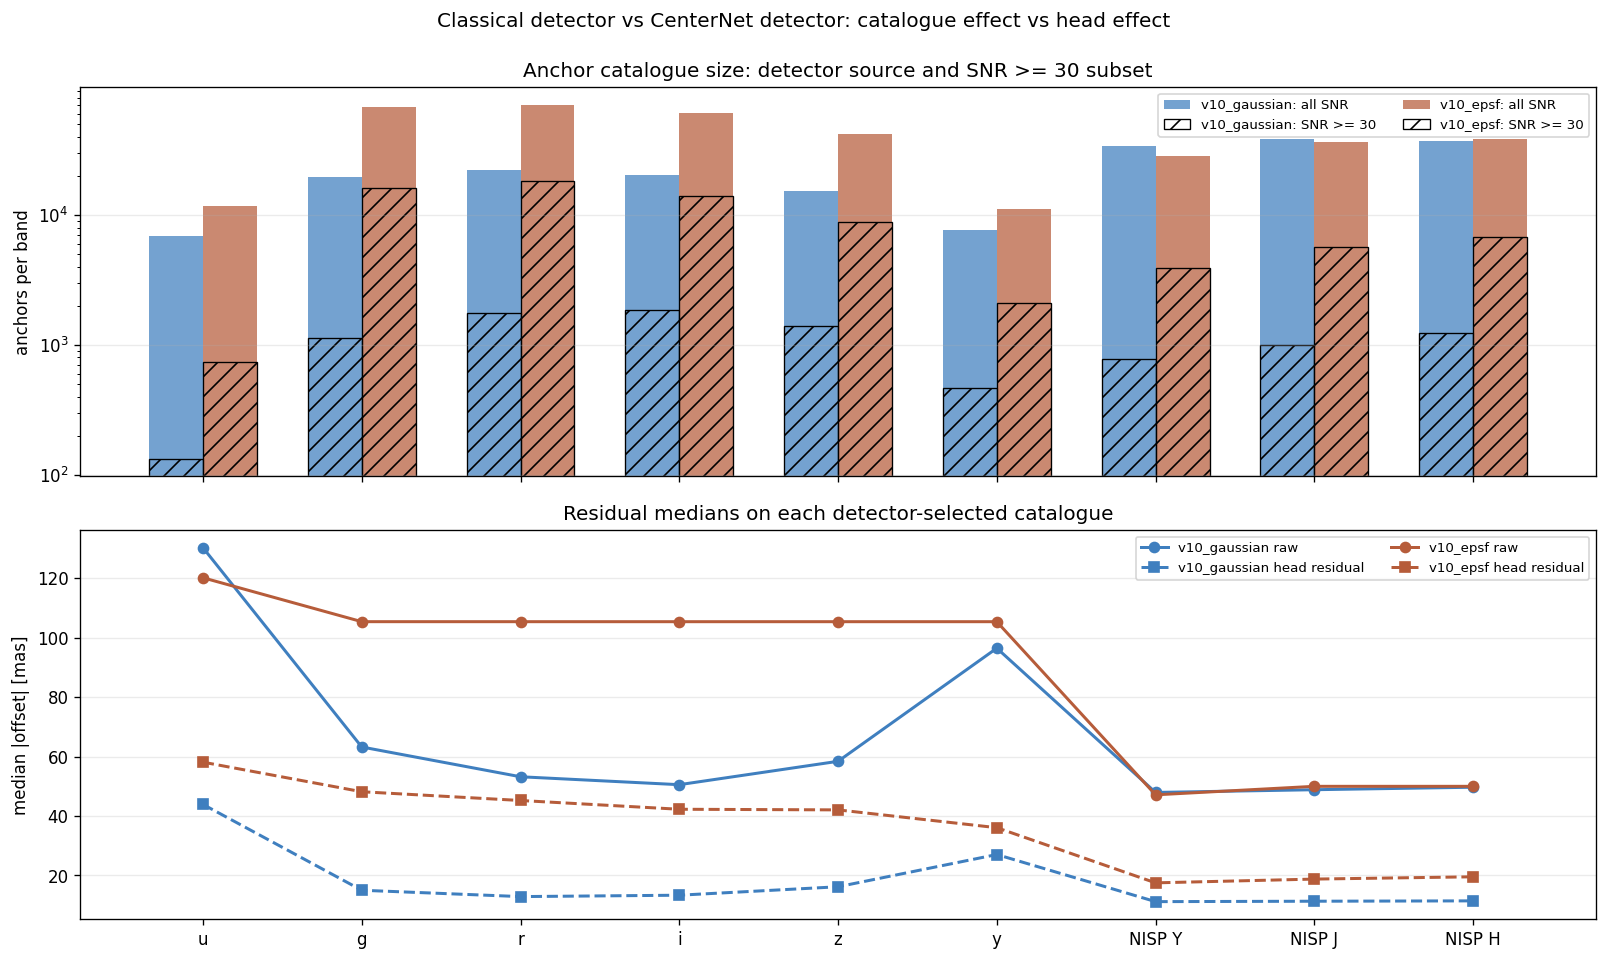

In [7]:
# Visual comparison: catalog size and raw/head residual medians by band.
if len(anchor_source_data) < 2:
    print("Only one anchor source available; skipping side-by-side plot.")
else:
    source_order = [s for s in ["v10_gaussian", "v10_epsf", "classical", "centernet"] if s in anchor_source_data]
    plot_bands = [b for b in ALL_BANDS if any(b in anchor_source_data[s] for s in source_order)]
    colors = {"v10_gaussian": "#3f7fbf", "v10_epsf": "#b65c3a", "classical": "#4c6a8a", "centernet": "#b65c3a"}
    x = np.arange(len(plot_bands))
    width = 0.34

    fig, axes = plt.subplots(2, 1, figsize=(13.5, 8.0), sharex=True)

    for i, source_name in enumerate(source_order):
        offset = (i - (len(source_order) - 1) / 2) * width
        counts_all, counts_classical, raw_meds, head_meds = [], [], [], []
        for band in plot_bands:
            d = anchor_source_data[source_name].get(band)
            if d is None:
                counts_all.append(np.nan); counts_classical.append(np.nan)
                raw_meds.append(np.nan); head_meds.append(np.nan)
                continue
            all_sel = source_pool_mask(d, "all")
            cls_sel = source_pool_mask(d, "classical")
            counts_all.append(int(all_sel.sum()))
            counts_classical.append(int(cls_sel.sum()))
            raw_meds.append(med_mas(d["raw"][all_sel]) if all_sel.any() else np.nan)
            head_meds.append(med_mas(d["head"][all_sel]) if all_sel.any() else np.nan)

        axes[0].bar(x + offset, counts_all, width=width, color=colors[source_name], alpha=0.72,
                    label=f"{source_name}: all SNR")
        axes[0].bar(x + offset, counts_classical, width=width, color="none", edgecolor="black",
                    linewidth=0.8, hatch="//", label=f"{source_name}: SNR >= {SNR_CLASSICAL:.0f}")
        axes[1].plot(x, raw_meds, marker="o", color=colors[source_name], linewidth=1.8,
                     label=f"{source_name} raw")
        axes[1].plot(x, head_meds, marker="s", color=colors[source_name], linewidth=1.8,
                     linestyle="--", label=f"{source_name} head residual")

    axes[0].set_yscale("log")
    axes[0].set_ylabel("anchors per band")
    axes[0].set_title("Anchor catalogue size: detector source and SNR >= 30 subset")
    axes[0].legend(fontsize=8, ncol=2)
    axes[0].grid(axis="y", alpha=0.25)

    axes[1].set_ylabel("median |offset| [mas]")
    axes[1].set_title("Residual medians on each detector-selected catalogue")
    axes[1].legend(fontsize=8, ncol=2)
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([display_band(b) for b in plot_bands])

    plt.suptitle("Classical detector vs CenterNet detector: catalogue effect vs head effect", y=0.995)
    plt.tight_layout()
    plt.savefig(FIGS / "anchor_source_comparison.png", dpi=220, bbox_inches="tight")
    plt.show()


## Part 2 -- Spatial field maps

Where on the sky is the offset concentrated, before and after the head?
Each row is one band; the four columns are:

1. **raw anchors** -- binned median `|offset|` from `anchors_v10_classical.npz`.
2. **PINN raw** -- smooth PINN field fit to those raw offsets.
3. **head-resid anchors** -- binned median of `_head_resid`, the
   per-source leftover after the head correction.
4. **PINN after head** -- smooth PINN field fit to the head residuals.

If the head absorbs the coherent component, the third column should look
less spatially coherent and the fourth should have a much smaller smooth
field amplitude. Small nonzero structure can still appear from sparse
coverage, noise, or residual systematics.


Per-column robust vmax (mas): raw=200, PINN_raw=20, head_resid=100, PINN_after_head=5


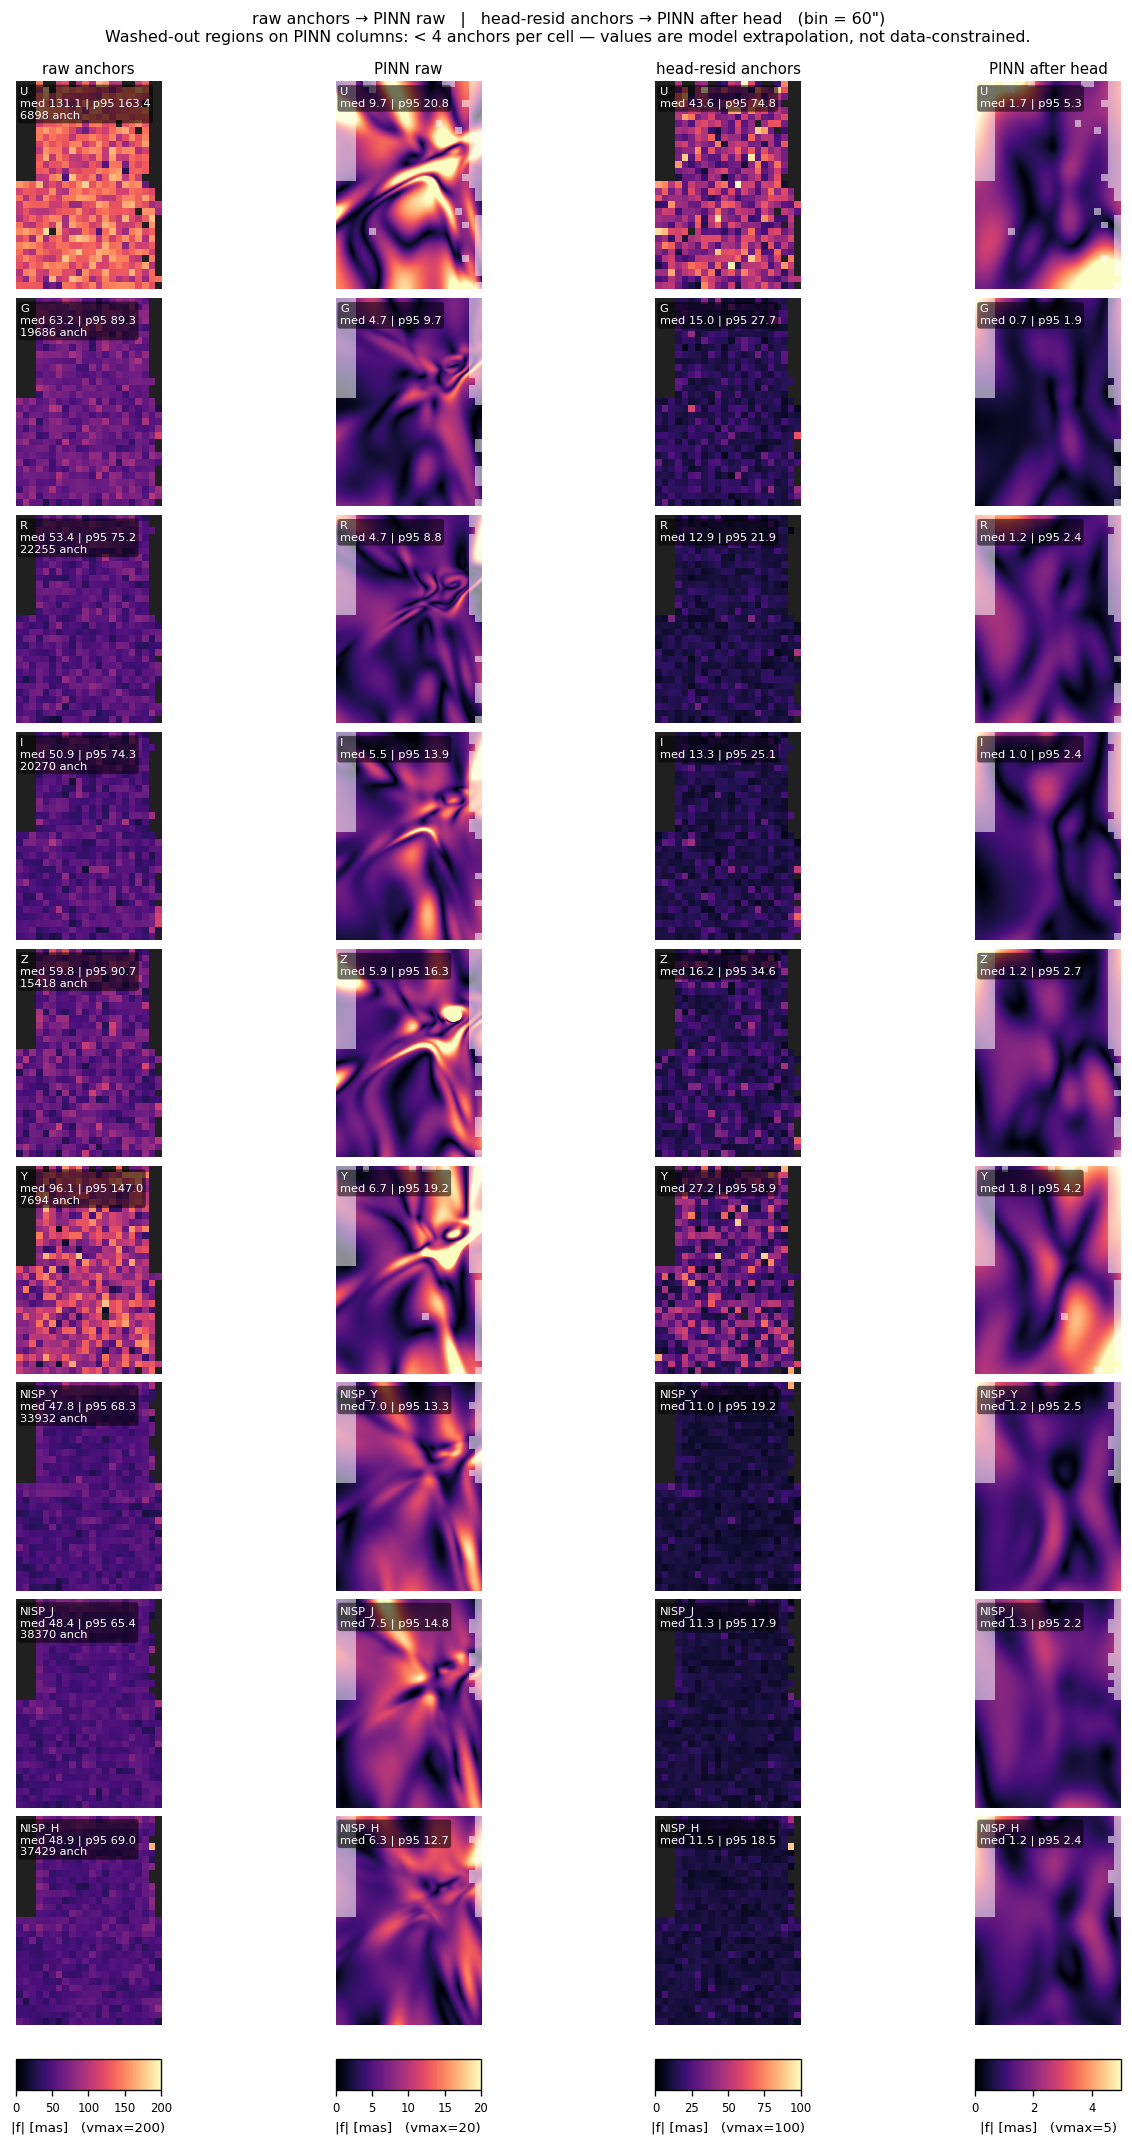

In [8]:
# 9x4 field comparison grid. Uses the PINN-raw FITS WCS to project anchors into a common sky frame.
# Per-column robust vmax (98th/95th percentile across all bands in that column) so outliers in a single
# panel do not blow out the scale, and a single colorbar at the bottom of each column rather than
# per-axis colorbars (saves horizontal space, lets columns sit closer together).
# Columns 1 and 3 (PINN model fields) are *dimmed* with a semi-transparent overlay in regions where
# the local anchor density is below MIN_COUNT, to flag PINN extrapolation versus data-constrained values.
BIN_ARCSEC = 60.0
MIN_COUNT = 4
MAS = 1000.0

with fits.open(FITS_PINN_RAW) as hdul:
    img_hdr = next(h.header for h in hdul[1:] if h.data is not None and h.data.ndim == 2)
    img_shape = next(h.data for h in hdul[1:] if h.data is not None and h.data.ndim == 2).shape
wcs_out = WCS(img_hdr)
image_h_pix, image_w_pix = img_shape
bin_px = max(1, int(round(BIN_ARCSEC / float(img_hdr.get("DSTEP", 1.0)))))
x_edges = np.arange(0, image_w_pix + bin_px, bin_px)
y_edges = np.arange(0, image_h_pix + bin_px, bin_px)


def bin_anchors(band, field_arr):
    """Return (median_grid, count_grid, n_anchors). count_grid is a 2D array of anchor counts per cell."""
    ra = data[band]["ra"]
    dec = data[band]["dec"]
    px, py = wcs_out.all_world2pix(ra, dec, 0)
    mag = np.hypot(field_arr[:, 0], field_arr[:, 1]) * MAS
    med, _, _, _ = binned_statistic_2d(px, py, mag, statistic="median", bins=[x_edges, y_edges])
    cnt, _, _, _ = binned_statistic_2d(px, py, mag, statistic="count", bins=[x_edges, y_edges])
    med = np.where(cnt >= MIN_COUNT, med, np.nan)
    return np.ma.masked_invalid(med.T), cnt.T.astype(int), int(len(ra))


def load_fits_fields(fits_path):
    out = {}
    with fits.open(fits_path) as hdul:
        for hdu in hdul[1:]:
            if hdu.data is None or not hdu.name or "." not in hdu.name:
                continue
            prefix, field = hdu.name.upper().rsplit(".", 1)
            out.setdefault(prefix, {})[field] = np.asarray(hdu.data, dtype=float)
    return out


pinn_raw_maps = load_fits_fields(FITS_PINN_RAW)
pinn_head_maps = load_fits_fields(FITS_PINN_HEAD)

# --- Pre-pass: collect all panels and per-band count grids. ---
panels_per_band = {}     # {band: [arr_col0, arr_col1, arr_col2, arr_col3]}
count_per_band = {}      # {band: count_grid}  (same for raw and head_resid, same anchors)
n_anchors_per_band = {}
for band in bands_present:
    ext = fits_ext(band)
    raw_bin, raw_cnt, n_anch = bin_anchors(band, data[band]["raw"])
    head_bin, _, _           = bin_anchors(band, data[band]["head"])
    pinn_raw_mag = np.ma.masked_invalid(
        np.hypot(pinn_raw_maps[ext]["DRA"], pinn_raw_maps[ext]["DDE"]) * MAS
    )
    pinn_head_mag = np.ma.masked_invalid(
        np.hypot(pinn_head_maps[ext]["DRA"], pinn_head_maps[ext]["DDE"]) * MAS
    )
    panels_per_band[band] = [raw_bin, pinn_raw_mag, head_bin, pinn_head_mag]
    count_per_band[band] = raw_cnt
    n_anchors_per_band[band] = n_anch

PERCENTILES = [95.0, 98.0, 95.0, 98.0]   # raw and head-resid columns are noisier -> tighter percentile


def _nice_vmax(v: float) -> float:
    """Round v up to 1/2/5 x 10^k for a tidy colorbar limit."""
    import math
    if not np.isfinite(v) or v <= 0:
        return 20.0
    exp = math.floor(math.log10(v))
    base = 10.0 ** exp
    norm = v / base
    if   norm <= 1.0:  return 1.0  * base
    elif norm <= 2.0:  return 2.0  * base
    elif norm <= 5.0:  return 5.0  * base
    else:              return 10.0 * base


per_col_vmax = []
for col, p in enumerate(PERCENTILES):
    pooled = []
    for band in bands_present:
        arr = panels_per_band[band][col]
        flat = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
        flat = flat[np.isfinite(flat)]
        if flat.size:
            pooled.append(flat)
    if pooled:
        all_vals = np.concatenate(pooled)
        per_col_vmax.append(_nice_vmax(float(np.nanpercentile(all_vals, p))))
    else:
        per_col_vmax.append(20.0)
print(f"Per-column robust vmax (mas): "
      f"raw={per_col_vmax[0]:.0f}, PINN_raw={per_col_vmax[1]:.0f}, "
      f"head_resid={per_col_vmax[2]:.0f}, PINN_after_head={per_col_vmax[3]:.0f}")


def make_extrap_overlay(count_grid: np.ndarray, alpha: float = 0.55) -> np.ndarray:
    """Build an RGBA overlay that is opaque white where count_grid < MIN_COUNT, transparent elsewhere.
    Renders 'unconstrained' PINN regions as washed-out, signalling extrapolation rather than measurement.
    """
    H, W = count_grid.shape
    rgba = np.zeros((H, W, 4), dtype=float)
    low = count_grid < MIN_COUNT
    rgba[..., 0:3] = 1.0           # white
    rgba[..., 3]   = low * alpha    # opaque only where data is sparse
    return rgba


cmap = mpl.colormaps["magma"].copy()
cmap.set_bad("#202020")
col_labels = ["raw anchors", "PINN raw", "head-resid anchors", "PINN after head"]

n_rows = len(bands_present)
fig, axes = plt.subplots(n_rows, 4, figsize=(11, 2.0 * n_rows), squeeze=False)

ims_per_col = [None, None, None, None]
for row, band in enumerate(bands_present):
    ext = fits_ext(band)
    raw_bin, pinn_raw_mag, head_bin, pinn_head_mag = panels_per_band[band]
    cnt_grid = count_per_band[band]
    panels = [
        (raw_bin,       [0, image_w_pix, 0, image_h_pix], False),
        (pinn_raw_mag,  None,                              True),   # overlay on PINN columns
        (head_bin,      [0, image_w_pix, 0, image_h_pix], False),
        (pinn_head_mag, None,                              True),
    ]
    for col, (arr, extent, dim_low_density) in enumerate(panels):
        ax = axes[row, col]
        kwargs = dict(cmap=cmap, vmin=0, vmax=per_col_vmax[col], interpolation="nearest")
        if extent is not None:
            kwargs["extent"] = extent
        im = ax.imshow(arr, **kwargs)
        ims_per_col[col] = im

        # Dim PINN-extrapolation regions on columns 1 and 3 using the count grid from columns 0 / 2.
        if dim_low_density:
            overlay = make_extrap_overlay(cnt_grid, alpha=0.55)
            ax.imshow(overlay, extent=[0, image_w_pix, 0, image_h_pix],
                      interpolation="nearest", zorder=2)

        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
        if row == 0:
            ax.set_title(col_labels[col], fontsize=9, pad=4)
        v = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
        v = v[np.isfinite(v)]
        med = np.nanmedian(v) if v.size else np.nan
        p95 = np.nanpercentile(v, 95) if v.size else np.nan
        extra = f"\n{n_anchors_per_band[band]} anch" if col == 0 else ""
        ax.text(
            0.03, 0.97, f"{ext}\nmed {med:.1f} | p95 {p95:.1f}{extra}",
            transform=ax.transAxes, va="top", ha="left", fontsize=6.8, color="white",
            bbox=dict(boxstyle="round,pad=0.22", facecolor="black", alpha=0.55, edgecolor="none"),
            zorder=4,
        )

# Tighten the layout: no per-axis colorbars, much smaller wspace.
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.06, top=0.96, hspace=0.04, wspace=0.04)

# One horizontal colorbar per column, anchored under the bottom row.
for col, im in enumerate(ims_per_col):
    if im is None:
        continue
    bbox_top = axes[-1, col].get_position()
    cbar_h = 0.014
    cbar_y = bbox_top.y0 - 0.030
    cax = fig.add_axes([bbox_top.x0, cbar_y, bbox_top.width, cbar_h])
    cb = fig.colorbar(im, cax=cax, orientation="horizontal")
    cb.set_label(f"|f| [mas]   (vmax={per_col_vmax[col]:.0f})", fontsize=8)
    cb.ax.tick_params(labelsize=7)

fig.suptitle(
    f"raw anchors → PINN raw   |   head-resid anchors → PINN after head   "
    f"(bin = {BIN_ARCSEC:.0f}\")\n"
    f"Washed-out regions on PINN columns: < {MIN_COUNT} anchors per cell — values are model "
    f"extrapolation, not data-constrained.",
    fontsize=9.5, y=0.992,
)
plt.savefig(FIGS / "concordance_3way.png", dpi=180, bbox_inches="tight")
plt.show()


## Part 3 -- Anchor Population

A classical bright-anchor concordance workflow leans on high-SNR, usually stellar or compact, anchors.
This section characterizes how many such anchors are available and where they live, so the
refits below are interpretable.

The notebook uses `SNR >= 30` as the classical bright-anchor cut. This is a practical
centroiding threshold, not a universal standard: for a seeing FWHM of roughly 0.7 arcsec,
the photon-noise centroid scale `FWHM / (2.35 * SNR)` is about 10 mas at SNR 30, before
PSF mismatch, blending, saturation and morphology systematics. For stricter astrometry,
`SNR >= 50` or `SNR >= 100` should be run as a sensitivity check.

- Per-band SNR distributions (log-x), including per-band terciles used only for diagnostic
  SNR slices.
- Spatial density at absolute SNR cuts (`<10`, `10-30`, `>=30`) for a representative band.
- Bright-anchor counts per occupied arcmin² cell, which is the resolution element used by
  the concordance maps.


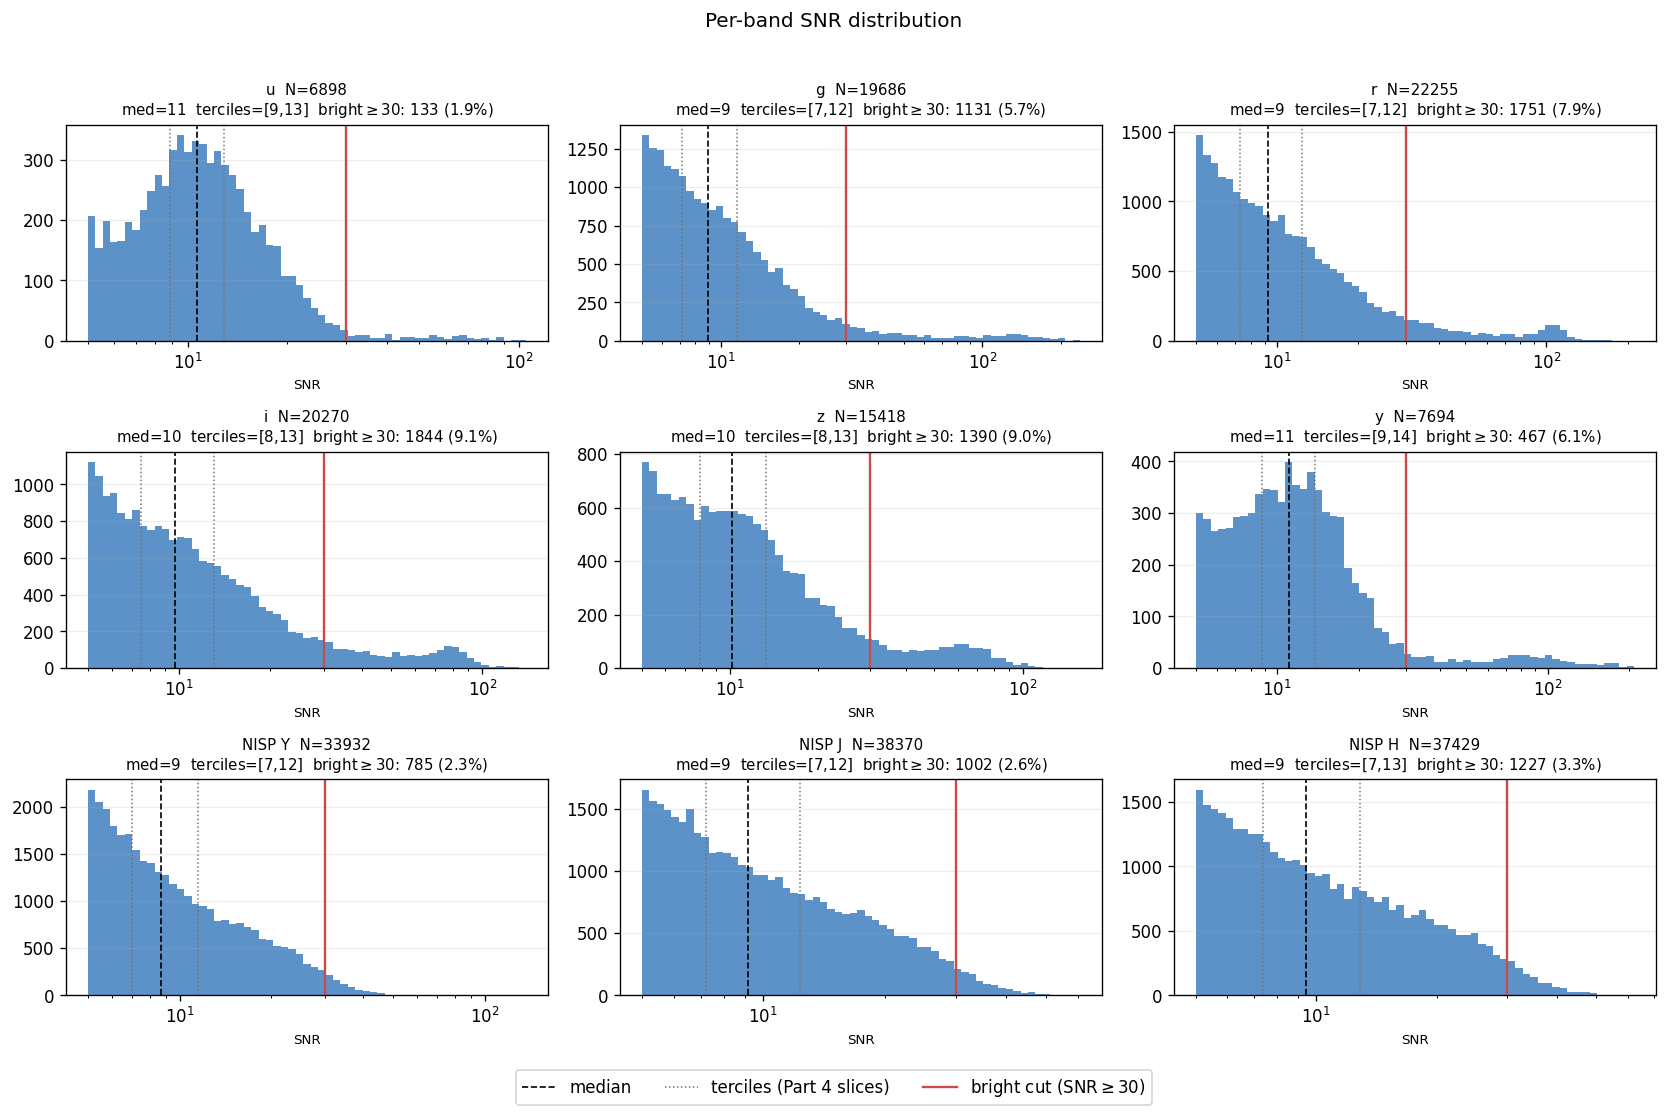

In [9]:
# Per-band SNR distributions.
# Three vertical reference lines per panel:
#   - dashed (median SNR): just descriptive
#   - dotted (33rd, 66th percentiles): the per-band tercile cuts used by the Part 4 PINN refits
#   - solid red (SNR = 30): the absolute "classical bright" threshold used by Part 3b leverage
# Single figure-level legend at the bottom so the panels stay clean.

SNR_BRIGHT_LINE = SNR_CLASSICAL   # matches SNR_BRIGHT in Part 3b and SNR_BRIGHT_ABS in cell 12

fig, axes = plt.subplots(3, 3, figsize=(14, 9))

handle_med = handle_terc = handle_bright = None

for ax, band in zip(axes.ravel(), bands_present):
    snr = data[band]["snr"]
    snr = snr[np.isfinite(snr) & (snr > 0)]
    if snr.size == 0:
        ax.text(0.5, 0.5, "no SNR", transform=ax.transAxes, ha="center")
        ax.set_title(display_band(band))
        continue
    bins = np.logspace(np.log10(max(snr.min(), 1.0)), np.log10(max(snr.max(), 10.0)), 60)
    ax.hist(snr, bins=bins, color="#3f7fbf", alpha=0.85)
    ax.set_xscale("log")
    ax.set_xlabel("SNR", fontsize=8)

    med = float(np.median(snr))
    p33, p66 = np.percentile(snr, [33.33, 66.67])
    n_bright = int((snr >= SNR_BRIGHT_LINE).sum())
    frac_bright = n_bright / snr.size * 100.0

    h_m = ax.axvline(med,  color="k",       lw=1.0, ls="--", label="median")
    h_t = ax.axvline(p33,  color="0.45",    lw=0.9, ls=":",  label="terciles (Part 4 slices)")
    ax.axvline(      p66,  color="0.45",    lw=0.9, ls=":")
    h_b = ax.axvline(SNR_BRIGHT_LINE, color="#c84b4b", lw=1.4, ls="-",
                     label=f"bright cut (SNR$\\geq${SNR_BRIGHT_LINE:.0f})")

    handle_med, handle_terc, handle_bright = h_m, h_t, h_b

    ax.set_title(
        f"{display_band(band)}  N={snr.size}\n"
        f"med={med:.0f}  terciles=[{p33:.0f},{p66:.0f}]  "
        f"bright$\\geq${SNR_BRIGHT_LINE:.0f}: {n_bright} ({frac_bright:.1f}%)",
        fontsize=9,
    )
    ax.grid(axis="y", alpha=0.2)

for ax in axes.ravel()[len(bands_present):]:
    ax.axis("off")

# Single figure-level legend at the bottom so all panels share it.
if handle_med is not None:
    fig.legend(
        [handle_med, handle_terc, handle_bright],
        [handle_med.get_label(), handle_terc.get_label(), handle_bright.get_label()],
        loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.015),
        frameon=True, fontsize=10,
    )

plt.suptitle("Per-band SNR distribution", y=1.005)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()


/home/shemmati/.local/lib/python3.9/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/home/shemmati/.local/lib/python3.9/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


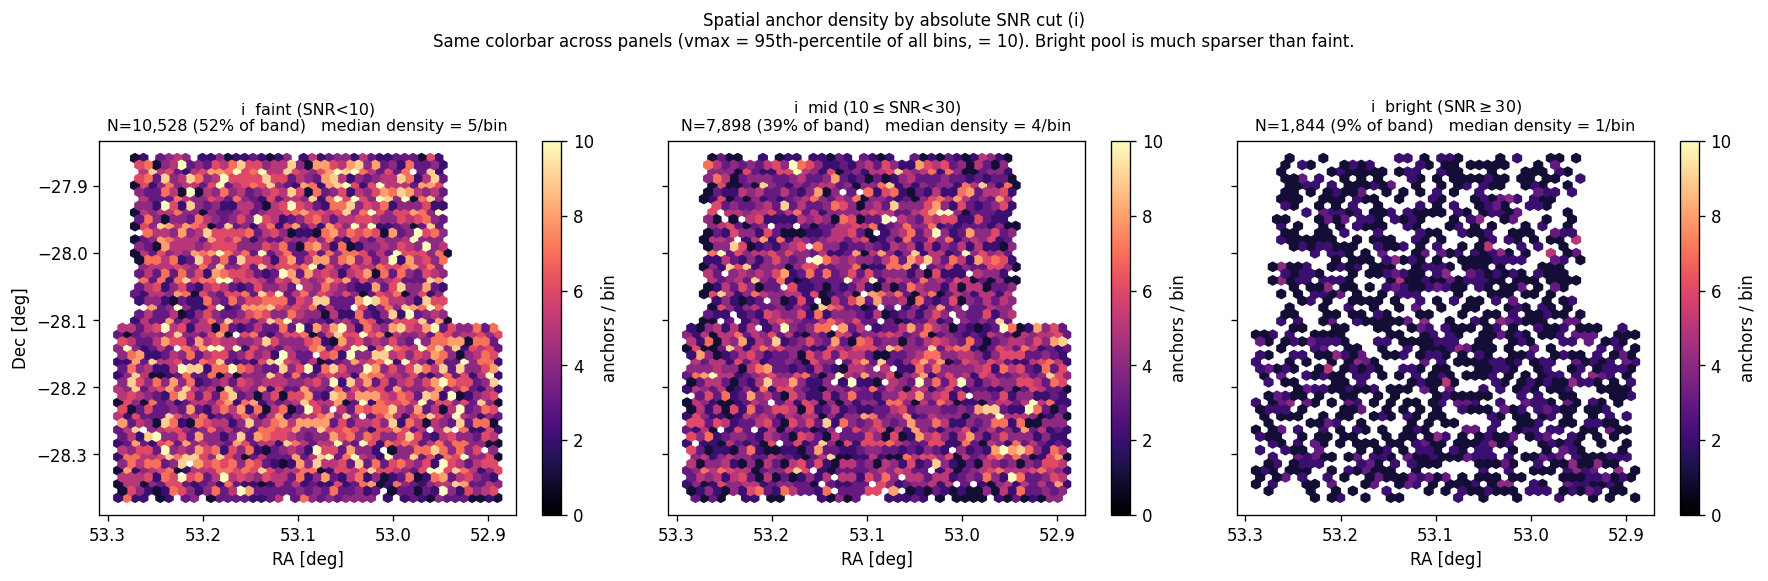


Total anchors in i: 20,270
  faint  (SNR < 10):                  10,528  (51.9%)
  mid    (10 ≤ SNR < 30):     7,898  (39.0%)
  bright (SNR ≥ 30):                 1,844  (9.1%)
  faint:bright ratio = 5.7× more faint than bright


In [10]:
# Spatial anchor density at three *absolute* SNR thresholds.
# Replaces the equal-size SNR-tercile panels (which by construction had ~equal N per panel,
# so all three looked the same density-wise) with absolute SNR cuts. The faint pool now
# carries many more anchors than the bright pool, and the colorbar contrast reflects that.
# All three panels share a single robust vmax (95th percentile across them) so a few hot hexes
# do not blow out the scale.

SNR_CUT_BRIGHT = SNR_CLASSICAL
SNR_CUT_MID    = SNR_MID_ABS

band_for_map = "i" if "i" in data else bands_present[0]
d = data[band_for_map]
snr = d["snr"]
ra_all, dec_all = d["ra"], d["dec"]
good = np.isfinite(snr) & (snr > 0)
n_total = int(good.sum())

masks = [
    (f"faint (SNR<{SNR_CUT_MID:.0f})",
     good & (snr < SNR_CUT_MID),                                          "#8b1a1a"),
    (f"mid ({SNR_CUT_MID:.0f}$\\leq$SNR<{SNR_CUT_BRIGHT:.0f})",
     good & (snr >= SNR_CUT_MID) & (snr < SNR_CUT_BRIGHT),                "#d18b20"),
    (f"bright (SNR$\\geq${SNR_CUT_BRIGHT:.0f})",
     good & (snr >= SNR_CUT_BRIGHT),                                      "#1d6ecf"),
]

extent = [ra_all.min(), ra_all.max(), dec_all.min(), dec_all.max()]
GRIDSIZE = 45

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7), sharex=True, sharey=True)

# Pass 1: draw the hexbin on each panel and remember the counts so we can pick a shared vmax.
hbs = []
panel_n = []
for ax, (name, mask, _color) in zip(axes, masks):
    n = int(mask.sum())
    panel_n.append(n)
    if n == 0:
        ax.text(0.5, 0.5, "empty", transform=ax.transAxes, ha="center")
        ax.set_title(f"{display_band(band_for_map)}  {name}  N=0", fontsize=10)
        hbs.append(None)
        continue
    hb = ax.hexbin(ra_all[mask], dec_all[mask], gridsize=GRIDSIZE,
                   cmap="magma", mincnt=1, extent=extent)
    hbs.append(hb)
    ax.set_xlabel("RA [deg]")
    ax.invert_xaxis()
axes[0].set_ylabel("Dec [deg]")

# Compute a shared, robust vmax from the union of all panel counts.
all_counts = np.concatenate([hb.get_array() for hb in hbs if hb is not None])
all_counts = all_counts[np.isfinite(all_counts) & (all_counts > 0)]
if all_counts.size:
    shared_vmax = float(np.percentile(all_counts, 95))
else:
    shared_vmax = 1.0
# Round to a tidy number.
import math as _m
if shared_vmax > 0:
    _exp = _m.floor(_m.log10(shared_vmax))
    _base = 10.0 ** _exp
    _norm = shared_vmax / _base
    shared_vmax = (1.0 if _norm <= 1 else 2.0 if _norm <= 2 else 5.0 if _norm <= 5 else 10.0) * _base

# Pass 2: apply the shared vmax, attach colorbar, write title with both N and median per-bin density.
for ax, (name, mask, _color), hb, n in zip(axes, masks, hbs, panel_n):
    if hb is None:
        continue
    hb.set_clim(0, shared_vmax)
    counts = hb.get_array()
    counts = counts[np.isfinite(counts) & (counts > 0)]
    med_density = float(np.median(counts)) if counts.size else 0.0
    frac = 100.0 * n / max(n_total, 1)
    ax.set_title(
        f"{display_band(band_for_map)}  {name}\n"
        f"N={n:,} ({frac:.0f}% of band)   median density = {med_density:.0f}/bin",
        fontsize=9.5,
    )
    plt.colorbar(hb, ax=ax, label="anchors / bin")

plt.suptitle(
    f"Spatial anchor density by absolute SNR cut ({display_band(band_for_map)})\n"
    f"Same colorbar across panels (vmax = 95th-percentile of all bins, "
    f"= {shared_vmax:.0f}). Bright pool is much sparser than faint.",
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()

print(f"\nTotal anchors in {display_band(band_for_map)}: {n_total:,}")
print(f"  faint  (SNR < {SNR_CUT_MID:.0f}):                {panel_n[0]:>8,}  ({100*panel_n[0]/n_total:.1f}%)")
print(f"  mid    ({SNR_CUT_MID:.0f} ≤ SNR < {SNR_CUT_BRIGHT:.0f}):  {panel_n[1]:>8,}  ({100*panel_n[1]/n_total:.1f}%)")
print(f"  bright (SNR ≥ {SNR_CUT_BRIGHT:.0f}):              {panel_n[2]:>8,}  ({100*panel_n[2]/n_total:.1f}%)")
print(f"  faint:bright ratio = {panel_n[0]/max(panel_n[2],1):.1f}× more faint than bright")


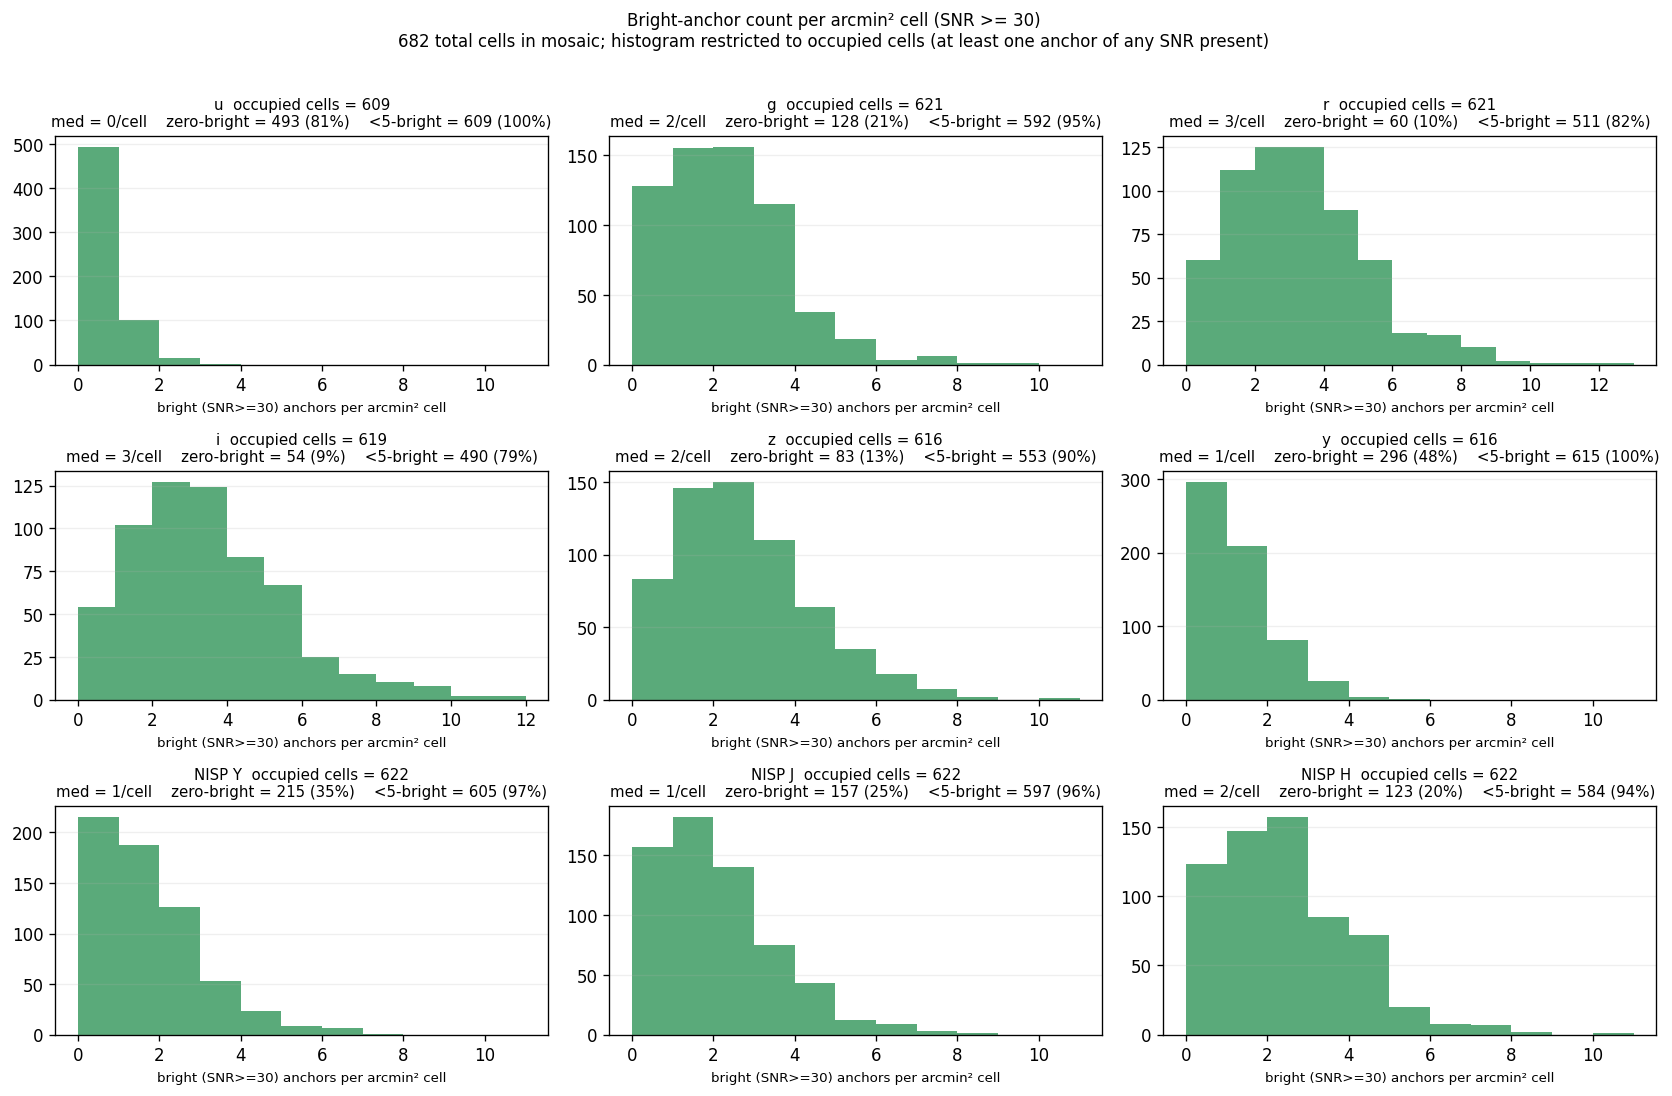

In [11]:
# Bright-anchor count distribution per arcmin² cell at the classical SNR cut.
# Switched from per-tile (variable tile sizes, not directly tied to field uncertainty) to
# per-arcmin² (the resolution element used by Part 3b's leverage figure and the existing
# 60" concordance map binning). The "zero" / "<5" statistics now describe the fraction of
# resolution elements where a classical bright-only concordance fit would be data-starved.

SNR_BRIGHT_ABS = SNR_CLASSICAL
ARCMIN = 60.0   # arcsec; matches Part 3b and the BIN_ARCSEC of the concordance maps

# Common tangent-plane frame across all bands so cells line up.
ra_full = np.concatenate([data[b]["ra"] for b in bands_present])
dec_full = np.concatenate([data[b]["dec"] for b in bands_present])
RA0_c = float(np.median(ra_full))
DEC0_c = float(np.median(dec_full))
cosdec_c = np.cos(np.deg2rad(DEC0_c))


def _xy_arcsec(ra, dec):
    return (
        (np.asarray(ra) - RA0_c) * cosdec_c * 3600.0,
        (np.asarray(dec) - DEC0_c) * 3600.0,
    )


x_full, y_full = _xy_arcsec(ra_full, dec_full)
edges_x_c = np.arange(x_full.min() - 1.0, x_full.max() + 1.0 + ARCMIN, ARCMIN)
edges_y_c = np.arange(y_full.min() - 1.0, y_full.max() + 1.0 + ARCMIN, ARCMIN)
n_cells_total = (len(edges_x_c) - 1) * (len(edges_y_c) - 1)

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, band in zip(axes.ravel(), bands_present):
    snr = data[band]["snr"]
    if snr.size == 0:
        ax.axis("off"); continue

    # Per-cell counts: bright (SNR >= 30) and total occupancy.
    x_all, y_all = _xy_arcsec(data[band]["ra"], data[band]["dec"])
    H_all, _, _ = np.histogram2d(x_all, y_all, bins=[edges_x_c, edges_y_c])
    bright_mask = np.isfinite(snr) & (snr >= SNR_BRIGHT_ABS)
    if bright_mask.sum() == 0:
        ax.text(0.5, 0.5, "no bright anchors", transform=ax.transAxes, ha="center")
        ax.set_title(display_band(band))
        continue
    xb, yb = _xy_arcsec(data[band]["ra"][bright_mask], data[band]["dec"][bright_mask])
    H_bright, _, _ = np.histogram2d(xb, yb, bins=[edges_x_c, edges_y_c])

    # Restrict the per-cell distribution to "occupied" cells (any anchor present).
    # A cell that is empty for all SNRs is outside the survey footprint or in a chip gap;
    # counting it as "zero bright" would conflate footprint with workflow weakness.
    occ = (H_all.ravel() > 0)
    bright_per_cell_occ = H_bright.ravel()[occ].astype(int)
    n_occ = int(occ.sum())

    # Histogram on integer bins.
    if bright_per_cell_occ.max() == 0:
        bins = np.arange(0, 3)
    else:
        bins = np.arange(0, max(int(bright_per_cell_occ.max()) + 2, 12))
    ax.hist(bright_per_cell_occ, bins=bins, color="#3d9b63", alpha=0.85)

    med = int(np.median(bright_per_cell_occ))
    n_zero = int((bright_per_cell_occ == 0).sum())
    n_poor = int((bright_per_cell_occ < 5).sum())
    ax.set_title(
        f"{display_band(band)}  occupied cells = {n_occ}\n"
        f"med = {med}/cell    zero-bright = {n_zero} ({100*n_zero/n_occ:.0f}%)    "
        f"<5-bright = {n_poor} ({100*n_poor/n_occ:.0f}%)",
        fontsize=9,
    )
    ax.set_xlabel(f"bright (SNR>={SNR_BRIGHT_ABS:.0f}) anchors per arcmin² cell", fontsize=8)
    ax.grid(axis="y", alpha=0.2)

for ax in axes.ravel()[len(bands_present):]:
    ax.axis("off")

plt.suptitle(
    f"Bright-anchor count per arcmin² cell (SNR >= {SNR_BRIGHT_ABS:.0f})\n"
    f"{n_cells_total} total cells in mosaic; histogram restricted to occupied cells "
    f"(at least one anchor of any SNR present)",
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()


## Part 3b -- Anchor Leverage And Per-Source Residual Scatter

Two headline diagnostics behind the case for a head-enabled concordance fit:

1. **Anchor density gain (per arcmin²).** A classical bright-only workflow (`SNR >= 30`)
   discards most of the matched-anchor catalogue. The head-enabled pool uses all matched
   anchors with finite positive SNR. We bin anchors on a 1 arcmin × 1 arcmin grid -- the
   same 60" scale used by the concordance field maps -- so the density metric matches the
   map resolution. This is a practical resolution element, not a claim that every field has
   exactly a 60" physical correlation length. The figure shows per-band median anchor density
   per occupied cell at the two thresholds and a cell-coverage curve. The per-cell density,
   not the per-tile count, is the quantity that enters the approximate smooth-field uncertainty:
   `σ_field ≈ σ_anchor / √(anchors per resolution element)`, when anchors are independent
   and have comparable errors.
2. **Per-source residual scatter.** MADxy of the raw (PSF-fit centroid) offset and of the
   `head_resid` per source. The ratio is an empirical residual-scatter improvement, not a
   pure centroid-noise measurement: it can still include training leakage, blending and
   unmodelled systematics. The right panel shows `|offset|` vs SNR for one band: the raw
   classical scatter follows the expected centroiding trend roughly proportional to
   `1/SNR`, while the head residual is much flatter.

Together these diagnostics say that the head-enabled pool has many more anchors per map
resolution element and lower empirical per-source residual scatter. That combination should
increase the statistical leverage of a smooth concordance fit, but the bootstrap/null and GP
checks below are what decide whether the recovered field is trustworthy.


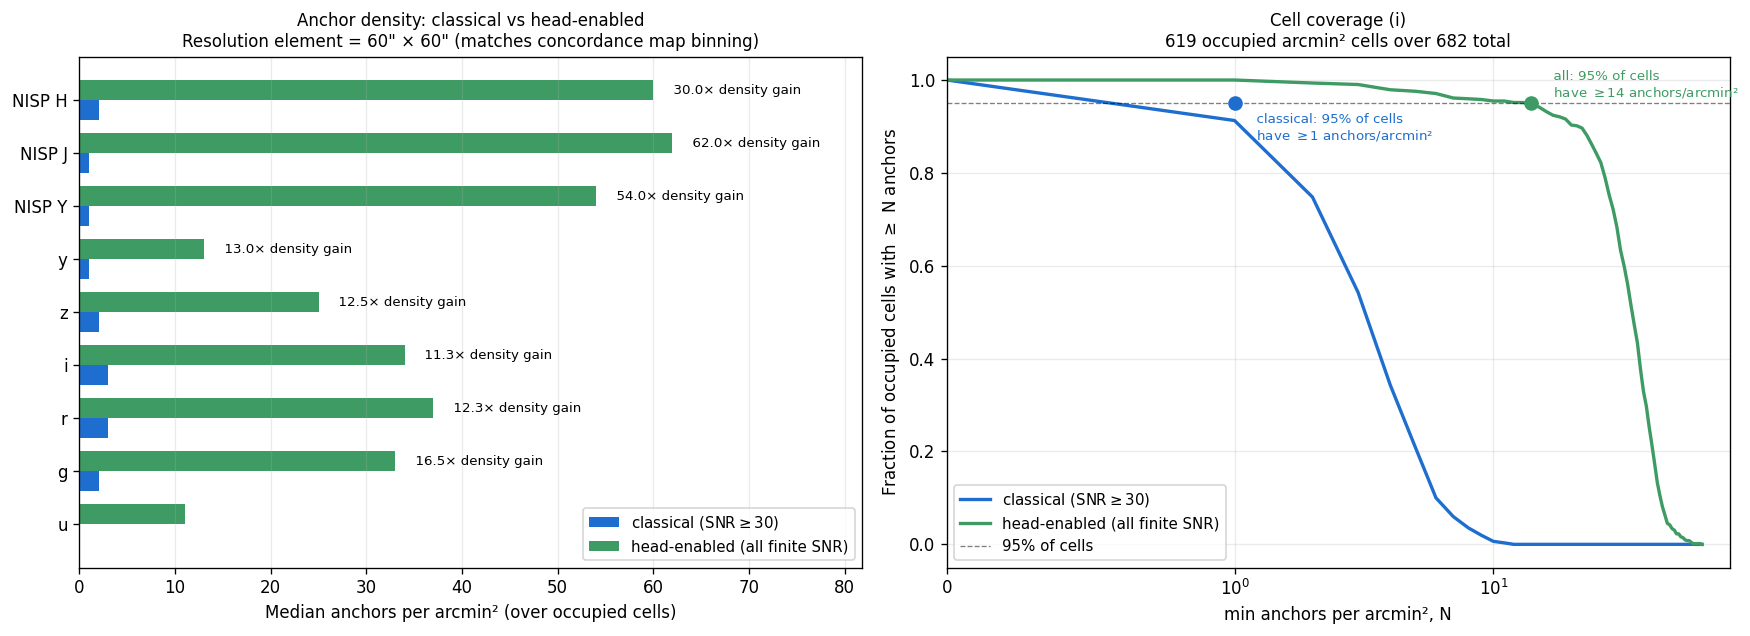


Resolution element: 60" × 60" = 1 arcmin² (matches concordance field-map bin)
Total cells in mosaic: 682

Per-band density (anchors / arcmin², median across occupied cells):
    Band     bright        all     × gain      N total
       u        0.0       11.0 11000000.0×        6,898
       g        2.0       33.0       16.5×       19,686
       r        3.0       37.0       12.3×       22,255
       i        3.0       34.0       11.3×       20,270
       z        2.0       25.0       12.5×       15,418
       y        1.0       13.0       13.0×        7,694
  NISP Y        1.0       54.0       54.0×       33,932
  NISP J        1.0       62.0       62.0×       38,370
  NISP H        2.0       60.0       30.0×       37,429


In [12]:
# === Anchor leverage: classical bright-only pool vs head-enabled pool, per arcmin^2 ===
# We bin anchors on a 1 arcmin x 1 arcmin grid in tangent-plane sky coordinates -- the same
# 60" scale used by the existing concordance field maps (BIN_ARCSEC=60 in Part 2). This is
# the natural correlation-length scale for a smooth WCS distortion field at survey level:
# anything finer than ~1' is below the WCS polynomial order, anything coarser washes out the
# coherent field structure. We then ask, per band, what the median per-cell anchor density is
# at each of two definitions, and what fraction of cells satisfies a minimum-N threshold:
#   - classical workflow: SNR >= SNR_BRIGHT (well-detected stars only)
#   - head-enabled: any matched anchor with finite, positive SNR

SNR_BRIGHT = SNR_CLASSICAL
ARCMIN = 60.0  # arcsec; the resolution element (1 arcmin x 1 arcmin)

# Common tangent-plane frame across all bands so the per-band cells line up exactly.
ra_full = np.concatenate([data[b]["ra"] for b in bands_present])
dec_full = np.concatenate([data[b]["dec"] for b in bands_present])
RA0_lev = float(np.median(ra_full))
DEC0_lev = float(np.median(dec_full))
cosdec = np.cos(np.deg2rad(DEC0_lev))


def _to_arcsec_xy(ra, dec):
    x = (np.asarray(ra) - RA0_lev) * cosdec * 3600.0
    y = (np.asarray(dec) - DEC0_lev) * 3600.0
    return x, y


x_full, y_full = _to_arcsec_xy(ra_full, dec_full)
x_lo, x_hi = float(x_full.min()) - 1.0, float(x_full.max()) + 1.0
y_lo, y_hi = float(y_full.min()) - 1.0, float(y_full.max()) + 1.0
edges_x = np.arange(x_lo, x_hi + ARCMIN, ARCMIN)
edges_y = np.arange(y_lo, y_hi + ARCMIN, ARCMIN)
n_cells_total = (len(edges_x) - 1) * (len(edges_y) - 1)


def _counts_per_cell(ra, dec, mask=None):
    x, y = _to_arcsec_xy(ra, dec)
    if mask is not None:
        x = x[mask]; y = y[mask]
    if x.size == 0:
        return np.zeros((len(edges_y) - 1, len(edges_x) - 1), dtype=int)
    H, _, _ = np.histogram2d(y, x, bins=[edges_y, edges_x])
    return H.astype(int)


# Per-band per-cell counts at both thresholds.
table_lev = []
counts_per_band = {}   # {band: (counts_bright_grid, counts_all_grid)}
for band in bands_present:
    d = data[band]
    snr = d["snr"]
    good = np.isfinite(snr) & (snr > 0)
    n_total = int(good.sum())
    n_bright = int((good & (snr >= SNR_BRIGHT)).sum())
    n_mid = int((good & (snr >= 5.0) & (snr < SNR_BRIGHT)).sum())
    n_faint = int((good & (snr < 5.0)).sum())
    grid_bright = _counts_per_cell(d["ra"], d["dec"], good & (snr >= SNR_BRIGHT))
    grid_all    = _counts_per_cell(d["ra"], d["dec"], good)
    table_lev.append((band, n_total, n_bright, n_mid, n_faint))
    counts_per_band[band] = (grid_bright, grid_all)

bands_l = [r[0] for r in table_lev]
totals  = np.array([r[1] for r in table_lev])
brights = np.array([r[2] for r in table_lev])
mids    = np.array([r[3] for r in table_lev])
faints  = np.array([r[4] for r in table_lev])


def _median_density(grid, occupancy):
    occ = grid[occupancy]
    return float(np.median(occ)) if occ.size else 0.0


med_density_bright = []
med_density_all = []
occupied_cells_per_band = []
for band in bands_l:
    g_b, g_a = counts_per_band[band]
    occupancy = g_a > 0
    occupied_cells_per_band.append(int(occupancy.sum()))
    med_density_bright.append(_median_density(g_b, occupancy))
    med_density_all.append(_median_density(g_a, occupancy))
med_density_bright = np.array(med_density_bright)
med_density_all = np.array(med_density_all)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

# Panel 1: per-band median anchor density per arcmin^2, classical vs head-enabled.
ax = axes[0]
y = np.arange(len(bands_l))
wbar = 0.38
ax.barh(y - wbar/2, med_density_bright, wbar, color="#1d6ecf",
        label=f"classical (SNR$\\geq${SNR_BRIGHT:.0f})")
ax.barh(y + wbar/2, med_density_all,    wbar, color="#3d9b63",
        label="head-enabled (all finite SNR)")
xmax = float(med_density_all.max())
for i, (b_, a_) in enumerate(zip(med_density_bright, med_density_all)):
    if b_ > 0:
        ratio = a_ / b_
        ax.text(a_ + 0.02 * xmax, i + wbar/2, f"  {ratio:.1f}× density gain",
                va="center", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels([display_band(b) for b in bands_l])
ax.set_xlabel("Median anchors per arcmin² (over occupied cells)")
ax.set_title(f"Anchor density: classical vs head-enabled\n"
             f"Resolution element = {ARCMIN:.0f}\" × {ARCMIN:.0f}\" "
             f"(matches concordance map binning)", fontsize=10)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.25)
ax.set_xlim(0, xmax * 1.32)

# Panel 2: cell-coverage curves -- fraction of cells with at least N anchors at each threshold,
# for one representative band. This is the per-resolution-element analogue of the per-tile coverage
# curve, and is the right metric for a smooth-field fit (anchors per resolution element drive the
# field uncertainty, not anchors per tile).
ax = axes[1]
band_for_cov = "i" if "i" in data else bands_present[0]
g_b, g_a = counts_per_band[band_for_cov]
occupied = (g_a > 0)
n_occ = int(occupied.sum())
counts_bright_flat = g_b[occupied]
counts_all_flat    = g_a[occupied]
n_max = max(int(counts_all_flat.max()) if n_occ else 1, 2)
N_axis = np.arange(0, n_max + 2)
frac_bright = np.array([(counts_bright_flat >= n).sum() / max(n_occ, 1) for n in N_axis])
frac_all    = np.array([(counts_all_flat    >= n).sum() / max(n_occ, 1) for n in N_axis])
ax.plot(N_axis, frac_bright, color="#1d6ecf", lw=2, label=f"classical (SNR$\geq${SNR_BRIGHT:.0f})")
ax.plot(N_axis, frac_all,    color="#3d9b63", lw=2, label="head-enabled (all finite SNR)")
ax.axhline(0.95, color="k", ls="--", lw=0.8, alpha=0.5, label="95% of cells")


def _N_at_frac(N_axis, frac, target=0.95):
    if frac.max() < target:
        return None
    return int(N_axis[np.searchsorted(-frac, -target)])


n95_bright = _N_at_frac(N_axis, frac_bright, 0.95)
n95_all    = _N_at_frac(N_axis, frac_all, 0.95)
if n95_bright is not None:
    ax.scatter([n95_bright], [0.95], color="#1d6ecf", s=60, zorder=5)
    ax.annotate(f"  classical: 95% of cells\n  have $\\geq${n95_bright} anchors/arcmin²",
                (n95_bright, 0.95), xytext=(8, -22), textcoords="offset points",
                fontsize=8, color="#1d6ecf")
if n95_all is not None:
    ax.scatter([n95_all], [0.95], color="#3d9b63", s=60, zorder=5)
    ax.annotate(f"  all: 95% of cells\n  have $\\geq${n95_all} anchors/arcmin²",
                (n95_all, 0.95), xytext=(8, 4), textcoords="offset points",
                fontsize=8, color="#3d9b63")
ax.set_xscale("symlog", linthresh=1)
ax.set_xlim(0, n_max * 1.3)
ax.set_xlabel("min anchors per arcmin², N")
ax.set_ylabel("Fraction of occupied cells with $\\geq$ N anchors")
ax.set_title(f"Cell coverage ({display_band(band_for_cov)})\n"
             f"{n_occ} occupied arcmin² cells over {n_cells_total} total",
             fontsize=10)
ax.legend(fontsize=9, loc="lower left")
ax.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.savefig(FIGS / "anchor_leverage_gain.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"\nResolution element: {ARCMIN:.0f}\" × {ARCMIN:.0f}\" = 1 arcmin² "
      f"(matches concordance field-map bin)")
print(f"Total cells in mosaic: {n_cells_total}\n")
print("Per-band density (anchors / arcmin², median across occupied cells):")
print(f'{"Band":>8} {"bright":>10} {"all":>10} {"× gain":>10} {"N total":>12}')
for i, b in enumerate(bands_l):
    g = med_density_all[i] / max(med_density_bright[i], 1e-6)
    print(f"{display_band(b):>8} {med_density_bright[i]:10.1f} {med_density_all[i]:10.1f} "
          f"{g:10.1f}× {totals[i]:12,}")


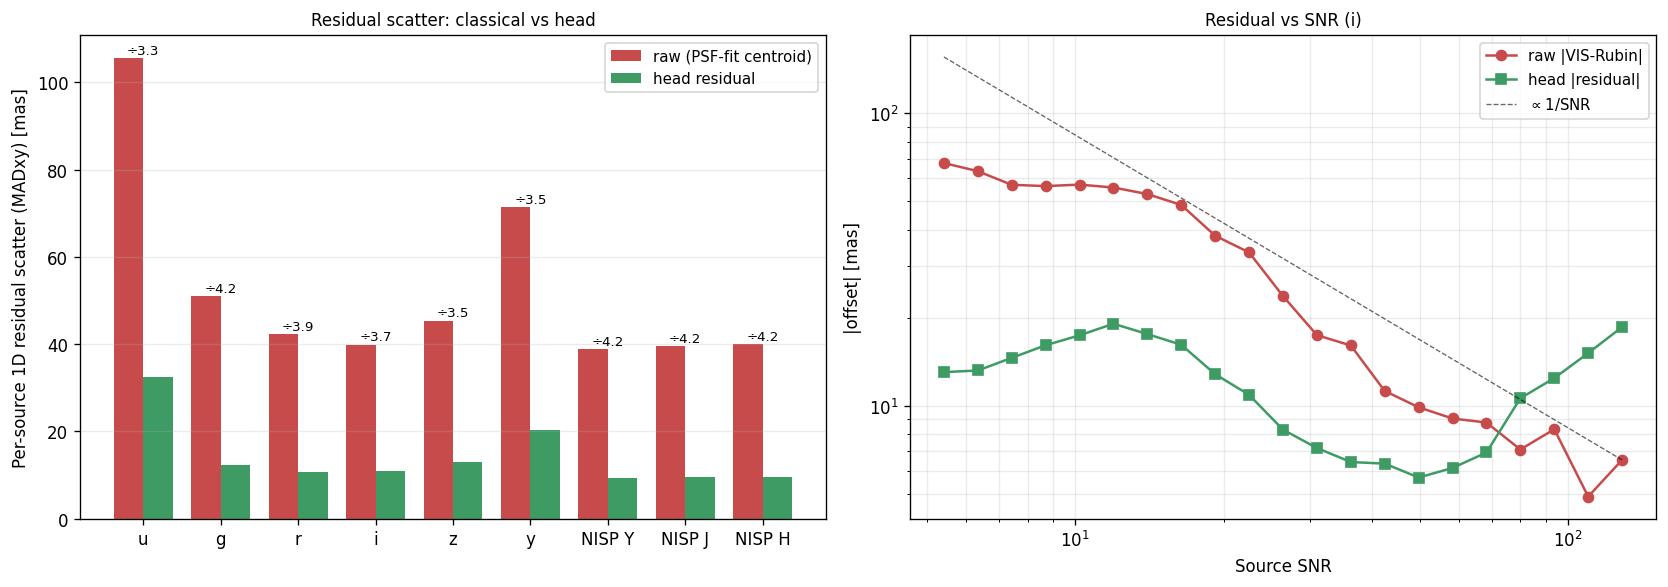


Per-band residual scatter (MADxy in mas):
    Band        raw       head     factor
       u      105.5       32.4        3.3×
       g       51.0       12.2        4.2×
       r       42.3       10.7        3.9×
       i       39.9       10.9        3.7×
       z       45.4       12.9        3.5×
       y       71.3       20.2        3.5×
  NISP Y       38.9        9.3        4.2×
  NISP J       39.5        9.5        4.2×
  NISP H       40.0        9.5        4.2×


In [13]:
# === Per-source residual scatter: raw centroids vs head residuals ===
# Use MADxy as an empirical per-source residual-scatter metric:
#   - on raw (= classical PSF-fit centroid VIS-vs-band offset): includes WCS field + per-source noise.
#   - on head_resid (= leftover after the head correction): residual scatter after the head.
#     This is not a pure centroid-noise floor; blending, morphology and train/test leakage can
#     contribute. The raw/head ratio is an empirical residual-scatter improvement factor.
# We also show how each scales with SNR for one band: classical centroids should roughly track
# PSF-width / SNR, while a useful head residual should be flatter if it is using context.

prec_rows = []
for band in bands_present:
    d = data[band]
    raw_madxy  = 0.5 * (mad_sigma(d["raw"][:, 0])  + mad_sigma(d["raw"][:, 1]))  * 1000.0   # mas
    head_madxy = 0.5 * (mad_sigma(d["head"][:, 0]) + mad_sigma(d["head"][:, 1])) * 1000.0
    prec_rows.append((band, raw_madxy, head_madxy))

bands_p = [r[0] for r in prec_rows]
raw_madxy_arr  = np.array([r[1] for r in prec_rows])
head_madxy_arr = np.array([r[2] for r in prec_rows])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: per-band paired bars with ratio annotation.
ax = axes[0]
xp = np.arange(len(bands_p))
wbar = 0.38
ax.bar(xp - wbar/2, raw_madxy_arr,  wbar, color="#c84b4b", label="raw (PSF-fit centroid)")
ax.bar(xp + wbar/2, head_madxy_arr, wbar, color="#3d9b63", label="head residual")
for i, (rv, hv) in enumerate(zip(raw_madxy_arr, head_madxy_arr)):
    if hv > 0:
        ax.text(xp[i], max(rv, hv) + 1.0, f"÷{rv/hv:.1f}", ha="center", fontsize=8)
ax.set_xticks(xp)
ax.set_xticklabels([display_band(b) for b in bands_p])
ax.set_ylabel("Per-source 1D residual scatter (MADxy) [mas]")
ax.set_title("Residual scatter: classical vs head", fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

# Panel 2: residual magnitude vs SNR for one representative band.
ax = axes[1]
band_for_snr = "i" if "i" in data else bands_present[0]
d = data[band_for_snr]
snr = d["snr"]
mag_raw  = mag_mas(d["raw"])
mag_head = mag_mas(d["head"])
ok = np.isfinite(snr) & (snr > 0)
snr_ok = snr[ok]; raw_ok = mag_raw[ok]; head_ok = mag_head[ok]
bins_snr = np.logspace(np.log10(max(snr_ok.min(), 3.0)), np.log10(snr_ok.max()), 22)
mid_b = np.sqrt(bins_snr[:-1] * bins_snr[1:])

def _running_med(y, x, edges):
    out = np.full(len(edges) - 1, np.nan)
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        m = (x >= lo) & (x < hi)
        if m.sum() > 5:
            out[i] = np.median(y[m])
    return out

med_raw  = _running_med(raw_ok,  snr_ok, bins_snr)
med_head = _running_med(head_ok, snr_ok, bins_snr)
ax.plot(mid_b, med_raw,  "o-", color="#c84b4b", label="raw |VIS-Rubin|")
ax.plot(mid_b, med_head, "s-", color="#3d9b63", label="head |residual|")
# Reference 1/SNR line, anchored to the brightest raw point.
finite_mask = np.isfinite(med_raw)
if finite_mask.any():
    fb = mid_b[finite_mask]
    fy = med_raw[finite_mask]
    j = int(np.argmax(fb))
    ref_y = fy[j] * fb[j] / mid_b
    ax.plot(mid_b, ref_y, "k--", lw=0.8, alpha=0.6, label=r"$\propto 1/\mathrm{SNR}$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Source SNR"); ax.set_ylabel("|offset| [mas]")
ax.set_title(f"Residual vs SNR ({display_band(band_for_snr)})", fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.savefig(FIGS / "per_source_precision.png", dpi=180, bbox_inches="tight")
plt.show()

print("\nPer-band residual scatter (MADxy in mas):")
print(f'{"Band":>8} {"raw":>10} {"head":>10} {"factor":>10}')
for b, rv, hv in prec_rows:
    print(f"{display_band(b):>8} {rv:10.1f} {hv:10.1f} {rv/max(hv,1e-6):10.1f}×")


## Part 4 -- Anchor-Pool PINN Refits

The main experiment. We refit the PINN jointly across all 9 bands for
several anchor pools, and we do it twice: once on raw offsets and once
on head residuals. The pools are deliberately separated into two kinds
of question:

- **`classical`**: absolute bright-anchor cut, `SNR >= 30`. This is a
  conventional high-SNR centroiding cut for a classical comparison, not a
  universal astrometric standard; rerun with `SNR >= 50` or `SNR >= 100`
  if the conclusion depends sensitively on the threshold.
- **`bright` / `mid` / `faint`**: per-band SNR terciles. These are
  diagnostic slices with equal-ish source counts per band, useful for
  testing SNR dependence.
- **`all`**: every finite positive-SNR anchor.

For each pool we fit:

- **raw anchors** (`{band}_raw`): measured band-to-VIS offsets.
- **head-residual anchors** (`{band}_head_resid`): per-source leftover
  after the latent position head.

Each refit uses capped, band-normalized SNR² weights. This follows the
centroiding intuition that variance scales roughly as `SNR^-2` within a
band, while avoiding the bad assumption that Rubin and NISP SNR values
live on one identical absolute noise scale.
The default refit is lighter than production so the notebook can finish
on GPU; use the environment variables in the cell below to increase the
step count for final numbers.


In [14]:
# Build per-slice anchor tables, then fit PINN jointly across bands.
N_STEPS_REFIT = int(_os.environ.get("NB07_N_STEPS_REFIT", "4000"))
N_COLLOC_REFIT = int(_os.environ.get("NB07_N_COLLOC_REFIT", "8000"))

# Common tangent-plane frame: compute ra0/dec0 from all anchors so every refit shares axes.
ra_all = np.concatenate([data[b]["ra"] for b in bands_present])
dec_all = np.concatenate([data[b]["dec"] for b in bands_present])
pos_all, RA0, DEC0 = sky_to_tangent_plane(ra_all, dec_all)
POS_MIN = pos_all.min(axis=0).astype(np.float32)
POS_MAX = pos_all.max(axis=0).astype(np.float32)
FIELD_W = int(np.ceil(float(POS_MAX[0] - POS_MIN[0]))) + 2
FIELD_H = int(np.ceil(float(POS_MAX[1] - POS_MIN[1]))) + 2
print(f"Common tangent frame: RA0={RA0:.4f} DEC0={DEC0:.4f}")
print(f"Field size (arcsec): {FIELD_W} x {FIELD_H}")


def tangent_shifted(ra, dec):
    cosdec = np.cos(np.deg2rad(DEC0))
    x = (np.asarray(ra) - RA0) * cosdec * 3600.0
    y = (np.asarray(dec) - DEC0) * 3600.0
    pos = np.stack([x, y], axis=1).astype(np.float32)
    return (pos - POS_MIN[None, :]).astype(np.float32)


SNR_SLICE_LABELS = {
    "all": "all",
    "classical": f"classical SNR >= {SNR_CLASSICAL:.0f}",
    "bright": "top tercile",
    "mid": "middle tercile",
    "faint": "bottom tercile",
}


def slice_label(snr_mode: str) -> str:
    return SNR_SLICE_LABELS.get(snr_mode, snr_mode)


# Per-band SNR reference scale. The solver still normalizes weights globally, so we first
# normalize each band's SNR leverage to its own typical good-anchor SNR and cap extremes.
SNR_WEIGHT_REF = {}
for band in bands_present:
    snr = data[band]["snr"]
    good = np.isfinite(snr) & (snr > 0)
    if good.any():
        clipped = np.clip(snr[good], SNR_WEIGHT_FLOOR, SNR_WEIGHT_CAP)
        SNR_WEIGHT_REF[band] = max(float(np.nanmedian(clipped)), SNR_WEIGHT_FLOOR)
    else:
        SNR_WEIGHT_REF[band] = SNR_WEIGHT_FLOOR


def snr_weights_for_band(band: str, snr_values: np.ndarray) -> np.ndarray:
    snr_c = np.clip(np.asarray(snr_values, dtype=np.float32), SNR_WEIGHT_FLOOR, SNR_WEIGHT_CAP)
    ref = max(float(SNR_WEIGHT_REF.get(band, SNR_WEIGHT_FLOOR)), SNR_WEIGHT_FLOOR)
    w = (snr_c / ref) ** 2
    return np.clip(w, SNR_WEIGHT_MIN, SNR_WEIGHT_MAX).astype(np.float32)


def build_slice(snr_mode: str, offset_key: str) -> dict | None:
    """snr_mode in {'all','classical','bright','mid','faint'}; offset_key in {'raw','head_resid'}.

    `classical` is the absolute SNR >= 30 pool. `bright`/`mid`/`faint` are per-band terciles.
    Returns dict with pos, offsets, weights, band_idx, n_per_band.
    """
    pos_list, off_list, w_list, bi_list, nper = [], [], [], [], {}
    for band in bands_present:
        d = data[band]
        snr = d["snr"]
        off = d["raw"] if offset_key == "raw" else d["head"]
        good = np.isfinite(snr) & (snr > 0)
        if good.sum() < 30:
            continue
        if snr_mode == "all":
            sel = good
        elif snr_mode == "classical":
            sel = good & (snr >= SNR_CLASSICAL)
        else:
            lo, hi = np.percentile(snr[good], [33.33, 66.67])
            if snr_mode == "bright":
                sel = good & (snr >= hi)
            elif snr_mode == "mid":
                sel = good & (snr >= lo) & (snr < hi)
            elif snr_mode == "faint":
                sel = good & (snr < lo)
            else:
                raise ValueError(snr_mode)
        if int(sel.sum()) < 30:
            continue
        pos = tangent_shifted(d["ra"][sel], d["dec"][sel])
        pos_list.append(pos)
        off_list.append(off[sel])
        w_list.append(snr_weights_for_band(band, snr[sel]))
        bi_list.append(np.full(int(sel.sum()), BAND_TO_IDX[band], dtype=np.int64))
        nper[band] = int(sel.sum())
    if not pos_list:
        return None
    return {
        "pos": np.concatenate(pos_list, axis=0),
        "offsets": np.concatenate(off_list, axis=0).astype(np.float32),
        "weights": np.concatenate(w_list, axis=0),
        "band_idx": np.concatenate(bi_list, axis=0),
        "n_per_band": nper,
    }


def fit_slice(slice_tab, tag):
    print(f"\n=== Fit {tag}  (N={len(slice_tab['pos'])}, bands={len(slice_tab['n_per_band'])}) ===")
    t0 = time.time()
    model, meta = fit_pinn_field(
        pos_arcsec=slice_tab["pos"],
        offsets_arcsec=slice_tab["offsets"],
        weights=slice_tab["weights"],
        band_indices=slice_tab["band_idx"],
        n_bands=N_BANDS,
        hidden_dim=128,
        n_layers=5,
        n_steps=N_STEPS_REFIT,
        lr=1e-3,
        lambda_curl=1.0,
        lambda_lapl=0.1,
        lambda_band=0.1,
        n_collocation=N_COLLOC_REFIT,
        device=DEVICE,
        verbose=False,
    )
    print(f"  done in {time.time() - t0:.1f}s  best_loss={meta['best_loss']:.4g}")
    return model, meta


SLICES = ["all", "classical", "bright", "mid", "faint"]
KINDS = ["raw", "head_resid"]
fits_store: dict[tuple[str, str], dict] = {}
for kind in KINDS:
    for snr_mode in SLICES:
        tab = build_slice(snr_mode, kind)
        if tab is None:
            print(f"Skipping {slice_label(snr_mode)} / {kind}: fewer than 30 anchors in every band")
            continue
        model, meta = fit_slice(tab, f"{slice_label(snr_mode)} / {kind}")
        fits_store[(snr_mode, kind)] = {
            "model": model, "meta": meta, "table": tab,
        }
print(f"\nCompleted {len(fits_store)} PINN refits")


Common tangent frame: RA0=53.0910 DEC0=-28.1299
Field size (arcsec): 1275 x 1829

=== Fit all / raw  (N=201952, bands=9) ===
  done in 171.7s  best_loss=0.1057

=== Fit classical SNR >= 30 / raw  (N=9730, bands=9) ===
  done in 74.6s  best_loss=0.1784

=== Fit top tercile / raw  (N=67313, bands=9) ===
  done in 91.6s  best_loss=0.0992

=== Fit middle tercile / raw  (N=67326, bands=9) ===
  done in 91.5s  best_loss=0.1995

=== Fit bottom tercile / raw  (N=67313, bands=9) ===
  done in 91.4s  best_loss=0.2268

=== Fit all / head_resid  (N=201952, bands=9) ===
  done in 164.4s  best_loss=0.09591

=== Fit classical SNR >= 30 / head_resid  (N=9730, bands=9) ===
  done in 74.8s  best_loss=0.2913

=== Fit top tercile / head_resid  (N=67313, bands=9) ===
  done in 91.6s  best_loss=0.1141

=== Fit middle tercile / head_resid  (N=67326, bands=9) ===
  done in 91.3s  best_loss=0.1689

=== Fit bottom tercile / head_resid  (N=67313, bands=9) ===
  done in 91.0s  best_loss=0.1743

Completed 10 PINN 

In [15]:
# Evaluate each fit on the common mesh (geometric field + per-band) and record amplitudes.
def eval_mesh(model, meta, band_idx_int=None):
    res = evaluate_pinn_mesh(
        model, meta, FIELD_H, FIELD_W, dstep=1,
        pos_arcsec_anchors=None, band_idx=band_idx_int,
    )
    return res


def field_rms_mas(res):
    dra = res["dra"] * 1000.0
    ddec = res["ddec"] * 1000.0
    return float(np.sqrt(np.nanmean(dra ** 2 + ddec ** 2)))


def field_p95_mas(res):
    mag = np.hypot(res["dra"], res["ddec"]) * 1000.0
    return float(np.nanpercentile(mag, 95))


summary_rows = []
for (snr_mode, kind), entry in fits_store.items():
    tab = entry["table"]
    # Residual at anchors.
    model = entry["model"]; meta = entry["meta"]
    pos_n = (tab["pos"] - meta["pos_min"]) / meta["pos_scale"] * 2.0 - 1.0
    with torch.no_grad():
        xy_t = torch.tensor(pos_n, dtype=torch.float32)
        bi_t = torch.tensor(tab["band_idx"], dtype=torch.long)
        pred = model(xy_t, band_idx=bi_t).numpy() * meta["off_scale"]
    resid = tab["offsets"] - pred
    # Geometric (achromatic) field on the mesh.
    geo = eval_mesh(model, meta, band_idx_int=None)
    summary_rows.append({
        "slice": slice_label(snr_mode), "kind": kind,
        "N": int(tab["pos"].shape[0]),
        "raw_med_mas": float(med_mas(tab["offsets"])),
        "resid_med_mas": float(med_mas(resid)),
        "field_rms_mas": field_rms_mas(geo),
        "field_p95_mas": field_p95_mas(geo),
    })
    entry["geo"] = geo
    entry["resid"] = resid

summary_tab = Table(rows=[(r["slice"], r["kind"], r["N"],
                           f"{r['raw_med_mas']:.1f}",
                           f"{r['resid_med_mas']:.1f}",
                           f"{r['field_rms_mas']:.1f}",
                           f"{r['field_p95_mas']:.1f}")
                          for r in summary_rows],
                   names=["slice", "kind", "N", "raw_med",
                          "resid_med", "field_rms", "field_p95"])
display(summary_tab)


slice,kind,N,raw_med,resid_med,field_rms,field_p95
str19,str10,int64,str4,str4,str4,str4
all,raw,201952,54.1,53.8,12.1,14.1
classical SNR >= 30,raw,9730,12.2,12.0,22.7,41.4
top tercile,raw,67313,30.1,29.3,3.3,4.6
middle tercile,raw,67326,58.1,57.7,8.6,11.8
bottom tercile,raw,67313,75.0,74.8,1.3,2.2
all,head_resid,201952,13.2,13.3,1.5,2.1
classical SNR >= 30,head_resid,9730,8.0,9.1,2.1,3.9
top tercile,head_resid,67313,9.8,9.8,5.0,5.8
middle tercile,head_resid,67326,14.9,15.4,2.9,4.2


## Part 4a -- Detector-Source Concordance Comparison

The Part 4 table above refits only the active anchor cache. This cell repeats the same
concordance-field fit for each available detector source on a common sky frame, restricted
to the two pools that matter for the detector/head question: all finite-SNR anchors and the
`SNR >= 30` classical slice.

Use the resulting table as the field-level decomposition:

- **Detector/catalog effect:** classical-cache raw field vs CenterNet-cache raw field.
- **Head effect:** raw field vs head-residual field within the same detector cache.
- **Combined AI pipeline:** classical-cache raw field vs CenterNet-cache head-residual field.

Set `NB07_RUN_SOURCE_REFITS=0` to skip this block, or increase
`NB07_N_STEPS_SOURCE_COMPARE` for final publication numbers.

In [16]:
# Field-level comparison of classical vs CenterNet anchor sources.
RUN_SOURCE_REFITS = _os.environ.get("NB07_RUN_SOURCE_REFITS", "1") != "0"
N_STEPS_SOURCE_COMPARE = int(_os.environ.get("NB07_N_STEPS_SOURCE_COMPARE", "2000"))
N_COLLOC_SOURCE_COMPARE = int(_os.environ.get("NB07_N_COLLOC_SOURCE_COMPARE", "5000"))
SOURCE_COMPARE_POOLS = ["all", "classical"]
SOURCE_COMPARE_KINDS = ["raw", "head_resid"]

source_compare_store: dict[tuple[str, str, str], dict] = {}

if not RUN_SOURCE_REFITS:
    print("Skipping source-comparison refits because NB07_RUN_SOURCE_REFITS=0")
elif len(anchor_source_data) < 2:
    print("Need both classical and CenterNet anchor caches for source-comparison refits.")
else:
    # Common tangent frame for both detector-selected catalogues.
    cmp_ra = []
    cmp_dec = []
    for src in anchor_source_data.values():
        for band in ALL_BANDS:
            if band not in src:
                continue
            sel = source_pool_mask(src[band], "all")
            if sel.any():
                cmp_ra.append(src[band]["ra"][sel])
                cmp_dec.append(src[band]["dec"][sel])
    cmp_ra = np.concatenate(cmp_ra)
    cmp_dec = np.concatenate(cmp_dec)
    cmp_pos_all, CMP_RA0, CMP_DEC0 = sky_to_tangent_plane(cmp_ra, cmp_dec)
    CMP_POS_MIN = cmp_pos_all.min(axis=0).astype(np.float32)
    CMP_POS_MAX = cmp_pos_all.max(axis=0).astype(np.float32)
    CMP_FIELD_W = int(np.ceil(float(CMP_POS_MAX[0] - CMP_POS_MIN[0]))) + 2
    CMP_FIELD_H = int(np.ceil(float(CMP_POS_MAX[1] - CMP_POS_MIN[1]))) + 2
    print(f"Source-comparison frame: RA0={CMP_RA0:.4f} DEC0={CMP_DEC0:.4f}")
    print(f"Source-comparison field size (arcsec): {CMP_FIELD_W} x {CMP_FIELD_H}")

    def compare_tangent_shifted(ra, dec):
        cosdec = np.cos(np.deg2rad(CMP_DEC0))
        x = (np.asarray(ra) - CMP_RA0) * cosdec * 3600.0
        y = (np.asarray(dec) - CMP_DEC0) * 3600.0
        pos = np.stack([x, y], axis=1).astype(np.float32)
        return (pos - CMP_POS_MIN[None, :]).astype(np.float32)

    # Per-source and per-band SNR reference scales, so CenterNet/classical catalogues are weighted
    # by their own typical good-anchor SNR without letting extreme SNR dominate.
    cmp_snr_ref = {}
    for source_name, src in anchor_source_data.items():
        for band in ALL_BANDS:
            if band not in src:
                continue
            snr = src[band]["snr"]
            good = source_pool_mask(src[band], "all")
            if good.any():
                clipped = np.clip(snr[good], SNR_WEIGHT_FLOOR, SNR_WEIGHT_CAP)
                cmp_snr_ref[(source_name, band)] = max(float(np.nanmedian(clipped)), SNR_WEIGHT_FLOOR)
            else:
                cmp_snr_ref[(source_name, band)] = SNR_WEIGHT_FLOOR

    def compare_snr_weights(source_name: str, band: str, snr_values: np.ndarray) -> np.ndarray:
        snr_c = np.clip(np.asarray(snr_values, dtype=np.float32), SNR_WEIGHT_FLOOR, SNR_WEIGHT_CAP)
        ref = max(float(cmp_snr_ref.get((source_name, band), SNR_WEIGHT_FLOOR)), SNR_WEIGHT_FLOOR)
        w = (snr_c / ref) ** 2
        return np.clip(w, SNR_WEIGHT_MIN, SNR_WEIGHT_MAX).astype(np.float32)

    def build_source_compare_slice(source_name: str, pool: str, kind: str) -> dict | None:
        src = anchor_source_data[source_name]
        pos_list, off_list, w_list, bi_list, nper = [], [], [], [], {}
        for band in ALL_BANDS:
            if band not in src:
                continue
            d = src[band]
            sel = source_pool_mask(d, pool)
            if int(sel.sum()) < 30:
                continue
            offsets = d["raw"] if kind == "raw" else d["head"]
            pos_list.append(compare_tangent_shifted(d["ra"][sel], d["dec"][sel]))
            off_list.append(offsets[sel])
            w_list.append(compare_snr_weights(source_name, band, d["snr"][sel]))
            bi_list.append(np.full(int(sel.sum()), BAND_TO_IDX[band], dtype=np.int64))
            nper[band] = int(sel.sum())
        if not pos_list:
            return None
        return {
            "pos": np.concatenate(pos_list, axis=0),
            "offsets": np.concatenate(off_list, axis=0).astype(np.float32),
            "weights": np.concatenate(w_list, axis=0),
            "band_idx": np.concatenate(bi_list, axis=0),
            "n_per_band": nper,
        }

    def fit_source_compare_slice(tab: dict, tag: str):
        print()
        print(f"=== Source compare {tag}  (N={len(tab['pos'])}, bands={len(tab['n_per_band'])}) ===")
        t0 = time.time()
        model, meta = fit_pinn_field(
            pos_arcsec=tab["pos"],
            offsets_arcsec=tab["offsets"],
            weights=tab["weights"],
            band_indices=tab["band_idx"],
            n_bands=N_BANDS,
            hidden_dim=128,
            n_layers=5,
            n_steps=N_STEPS_SOURCE_COMPARE,
            lr=1e-3,
            lambda_curl=1.0,
            lambda_lapl=0.1,
            lambda_band=0.1,
            n_collocation=N_COLLOC_SOURCE_COMPARE,
            device=DEVICE,
            verbose=False,
        )
        print(f"  done in {time.time() - t0:.1f}s  best_loss={meta['best_loss']:.4g}")
        return model, meta

    for source_name in [s for s in ["classical", "centernet"] if s in anchor_source_data]:
        for pool in SOURCE_COMPARE_POOLS:
            for kind in SOURCE_COMPARE_KINDS:
                tab = build_source_compare_slice(source_name, pool, kind)
                if tab is None:
                    print(f"Skipping {source_name} / {pool} / {kind}: too few anchors")
                    continue
                model, meta = fit_source_compare_slice(tab, f"{source_name} / {pool} / {kind}")
                geo = evaluate_pinn_mesh(model, meta, CMP_FIELD_H, CMP_FIELD_W, dstep=1, band_idx=None)
                source_compare_store[(source_name, pool, kind)] = {
                    "model": model, "meta": meta, "table": tab, "geo": geo,
                    "field_rms_mas": field_rms_mas(geo),
                    "field_p95_mas": field_p95_mas(geo),
                }

    rows = []
    for (source_name, pool, kind), entry in source_compare_store.items():
        rows.append((
            source_name,
            {"all": "all SNR", "classical": f"SNR >= {SNR_CLASSICAL:.0f}"}[pool],
            kind,
            int(entry["table"]["pos"].shape[0]),
            f"{med_mas(entry['table']['offsets']):.1f}",
            f"{entry['field_rms_mas']:.2f}",
            f"{entry['field_p95_mas']:.2f}",
        ))
    if rows:
        source_field_tab = Table(
            rows=rows,
            names=["source", "pool", "kind", "N", "anchor_med", "field_rms", "field_p95"],
        )
        display(source_field_tab)
    else:
        print("No classical/CenterNet source-refit products were produced; skipping this optional old comparison.")

    decomp_rows = []
    for pool in SOURCE_COMPARE_POOLS:
        cr = source_compare_store.get(("classical", pool, "raw"))
        ch = source_compare_store.get(("classical", pool, "head_resid"))
        nr = source_compare_store.get(("centernet", pool, "raw"))
        nh = source_compare_store.get(("centernet", pool, "head_resid"))
        if not all([cr, ch, nr, nh]):
            continue
        decomp_rows.append((
            {"all": "all SNR", "classical": f"SNR >= {SNR_CLASSICAL:.0f}"}[pool],
            f"{cr['field_rms_mas']:.2f}",
            f"{nr['field_rms_mas']:.2f}",
            f"{100.0 * (1.0 - nr['field_rms_mas'] / cr['field_rms_mas']):.1f}",
            f"{100.0 * (1.0 - ch['field_rms_mas'] / cr['field_rms_mas']):.1f}",
            f"{100.0 * (1.0 - nh['field_rms_mas'] / nr['field_rms_mas']):.1f}",
            f"{100.0 * (1.0 - nh['field_rms_mas'] / cr['field_rms_mas']):.1f}",
        ))
    if decomp_rows:
        source_field_decomp_tab = Table(
            rows=decomp_rows,
            names=[
                "pool", "field_classical_raw", "field_centernet_raw", "detector_delta_%",
                "head_gain_classical_%", "head_gain_centernet_%", "combined_gain_%",
            ],
        )
        display(source_field_decomp_tab)

    if source_compare_store:
        labels = []
        vals = []
        colors = []
        color_map = {"classical": "#4c6a8a", "centernet": "#b65c3a"}
        for source_name in ["classical", "centernet"]:
            for pool in SOURCE_COMPARE_POOLS:
                for kind in SOURCE_COMPARE_KINDS:
                    entry = source_compare_store.get((source_name, pool, kind))
                    if entry is None:
                        continue
                    labels.append(f"{source_name}\\n{pool}\\n{kind}")
                    vals.append(entry["field_rms_mas"])
                    colors.append(color_map[source_name])
        fig, ax = plt.subplots(figsize=(11.5, 4.8))
        bars = ax.bar(np.arange(len(vals)), vals, color=colors, alpha=0.82)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.05, f"{val:.1f}",
                    ha="center", va="bottom", fontsize=8)
        ax.set_xticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel("geometric field RMS [mas]")
        ax.set_title("Concordance field amplitude by detector source, SNR pool and correction stage")
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.savefig(FIGS / "anchor_source_concordance_comparison.png", dpi=220, bbox_inches="tight")
        plt.show()


Source-comparison frame: RA0=53.0916 DEC0=-28.1322
Source-comparison field size (arcsec): 1275 x 1829
No classical/CenterNet source-refit products were produced; skipping this optional old comparison.


## Part 4b -- Bootstrap and shuffled-null tests: how much to trust the field

The Part 4 summary table prints a single field-RMS number per slice and per kind. Two questions
are not answered by that single number:

1. **What is the statistical uncertainty on the field RMS?** A point estimate of "5.2 mas" is
   meaningless without a bootstrap error bar.
2. **What does the PINN do on data with no spatial coherence?** Even pure noise, fed to a
   flexible smoothness-regularised network, can produce a non-zero field. We need a noise floor:
   the field RMS the PINN extracts after spatial structure is destroyed.

The cell below does both, with two safeguards for the joint multi-band setting:

- Bootstrap resampling is stratified by band, so band counts are preserved.
- The shuffled null permutes positions *within each band*, preserving each band's footprint,
  SNR/weight distribution and offset distribution while destroying position-offset coherence.

The default settings are still notebook-speed settings. For final numbers, set for example
`NB07_N_BOOT=10`, `NB07_N_STEPS_FAST=4000`, and `NB07_N_COLLOC_FAST=8000` before running.


In [17]:
# === Trustworthiness diagnostics: bootstrap field RMS + shuffled null test ===
# Two complementary tests that the smooth field we fit is real signal, not noise the PINN absorbed.
#
#   (a) Bootstrap. Resample anchors with replacement, stratified by band, refit the PINN,
#       and record the field RMS. Std across resamples = statistical uncertainty.
#   (b) Shuffled null. Permute positions within each band while keeping offsets, weights and
#       band labels fixed. The null keeps each band's footprint and noise distribution but
#       destroys spatial coherence by construction.

import time as _time

N_BOOT = int(_os.environ.get("NB07_N_BOOT", "5"))
N_STEPS_FAST = int(_os.environ.get("NB07_N_STEPS_FAST", "1500"))
N_COLLOC_FAST = int(_os.environ.get("NB07_N_COLLOC_FAST", "4000"))
SUBSAMPLE_CAP = int(_os.environ.get("NB07_SUBSAMPLE_CAP", "60000"))
RNG = np.random.default_rng(0)
IDX_TO_BAND = {v: k for k, v in BAND_TO_IDX.items()}


def _eval_field_rms(model, meta) -> float:
    res = evaluate_pinn_mesh(model, meta, FIELD_H, FIELD_W, dstep=1, band_idx=None)
    return float(np.sqrt(np.nanmean((res["dra"] * 1000.0) ** 2 + (res["ddec"] * 1000.0) ** 2)))


def _quick_fit(pos, off, w, bi):
    m, mt = fit_pinn_field(
        pos_arcsec=pos, offsets_arcsec=off, weights=w,
        band_indices=bi, n_bands=N_BANDS,
        n_steps=N_STEPS_FAST, n_collocation=N_COLLOC_FAST,
        device=DEVICE, verbose=False,
    )
    return _eval_field_rms(m, mt)


def _tab_from_indices(tab, idx):
    idx = np.asarray(idx, dtype=np.int64)
    bi = tab["band_idx"][idx]
    n_per_band = {IDX_TO_BAND.get(int(b), str(int(b))): int((bi == b).sum()) for b in np.unique(bi)}
    return {
        "pos": tab["pos"][idx], "offsets": tab["offsets"][idx],
        "weights": tab["weights"][idx], "band_idx": bi,
        "n_per_band": n_per_band,
    }


def _maybe_subsample(tab, cap):
    N = len(tab["pos"])
    if N <= cap:
        return tab
    pieces = []
    for b in np.unique(tab["band_idx"]):
        idx_b = np.flatnonzero(tab["band_idx"] == b)
        n_keep = max(1, int(round(cap * len(idx_b) / N)))
        n_keep = min(n_keep, len(idx_b))
        pieces.append(RNG.choice(idx_b, size=n_keep, replace=False))
    idx = np.concatenate(pieces)
    if len(idx) > cap:
        idx = RNG.choice(idx, size=cap, replace=False)
    return _tab_from_indices(tab, np.sort(idx))


def _bootstrap_indices_within_band(tab):
    pieces = []
    for b in np.unique(tab["band_idx"]):
        idx_b = np.flatnonzero(tab["band_idx"] == b)
        pieces.append(RNG.choice(idx_b, size=len(idx_b), replace=True))
    return np.concatenate(pieces)


def _permute_pos_within_band(tab):
    pos_null = tab["pos"].copy()
    for b in np.unique(tab["band_idx"]):
        idx_b = np.flatnonzero(tab["band_idx"] == b)
        pos_null[idx_b] = tab["pos"][RNG.permutation(idx_b)]
    return pos_null


trust_rows = []
total_fits = len(SLICES) * len(KINDS) * (N_BOOT + 1)
done = 0
for snr_mode in SLICES:
    for kind in KINDS:
        tab_full = build_slice(snr_mode, kind)
        if tab_full is None:
            continue
        tab = _maybe_subsample(tab_full, SUBSAMPLE_CAP)
        N = len(tab["pos"])

        # Bootstrap on real data, preserving per-band counts.
        boot_real = []
        for b in range(N_BOOT):
            idx = _bootstrap_indices_within_band(tab)
            t0 = _time.time()
            rms = _quick_fit(tab["pos"][idx], tab["offsets"][idx], tab["weights"][idx], tab["band_idx"][idx])
            boot_real.append(rms)
            done += 1
            print(f"  [{done}/{total_fits}] boot {slice_label(snr_mode)}/{kind} #{b+1}/{N_BOOT}  RMS={rms:5.2f} mas  ({_time.time()-t0:.0f}s)")
        boot_real = np.array(boot_real)

        # Shuffled null: permute positions within band only.
        pos_null = _permute_pos_within_band(tab)
        t0 = _time.time()
        rms_null = _quick_fit(pos_null, tab["offsets"], tab["weights"], tab["band_idx"])
        done += 1
        print(f"  [{done}/{total_fits}] null {slice_label(snr_mode)}/{kind}              RMS={rms_null:5.2f} mas  ({_time.time()-t0:.0f}s)")

        trust_rows.append({
            "slice": snr_mode, "kind": kind, "N_used": N, "N_full": len(tab_full["pos"]),
            "rms_mean": float(boot_real.mean()),
            "rms_std":  float(boot_real.std(ddof=1)) if N_BOOT > 1 else 0.0,
            "rms_null": float(rms_null),
            "snr_significance": float(boot_real.mean() / max(rms_null, 1e-6)),
        })

trust_tab = Table(rows=[(slice_label(r["slice"]), r["kind"], r["N_used"], r["N_full"],
                          f"{r['rms_mean']:.2f}±{r['rms_std']:.2f}",
                          f"{r['rms_null']:.2f}",
                          f"{r['snr_significance']:.1f}×")
                          for r in trust_rows],
                  names=["slice", "kind", "N_used", "N_full", "field RMS [mas]",
                         "null RMS [mas]", "signal/null"])
display(trust_tab)


  [1/60] boot all/raw #1/5  RMS= 3.11 mas  (33s)
  [2/60] boot all/raw #2/5  RMS= 6.01 mas  (32s)
  [3/60] boot all/raw #3/5  RMS= 3.99 mas  (32s)
  [4/60] boot all/raw #4/5  RMS= 7.22 mas  (32s)
  [5/60] boot all/raw #5/5  RMS= 7.81 mas  (32s)
  [6/60] null all/raw              RMS= 5.08 mas  (32s)
  [7/60] boot all/head_resid #1/5  RMS= 1.28 mas  (32s)
  [8/60] boot all/head_resid #2/5  RMS= 2.47 mas  (32s)
  [9/60] boot all/head_resid #3/5  RMS= 7.15 mas  (32s)
  [10/60] boot all/head_resid #4/5  RMS= 4.29 mas  (32s)
  [11/60] boot all/head_resid #5/5  RMS= 1.98 mas  (32s)
  [12/60] null all/head_resid              RMS= 2.42 mas  (32s)
  [13/60] boot classical SNR >= 30/raw #1/5  RMS=23.71 mas  (28s)
  [14/60] boot classical SNR >= 30/raw #2/5  RMS= 3.38 mas  (28s)
  [15/60] boot classical SNR >= 30/raw #3/5  RMS=15.58 mas  (28s)
  [16/60] boot classical SNR >= 30/raw #4/5  RMS= 3.90 mas  (28s)
  [17/60] boot classical SNR >= 30/raw #5/5  RMS= 7.40 mas  (28s)
  [18/60] null classica

slice,kind,N_used,N_full,field RMS [mas],null RMS [mas],signal/null
str19,str10,int64,int64,str10,str5,str4
all,raw,60000,201952,5.63±2.03,5.08,1.1×
all,head_resid,60000,201952,3.43±2.36,2.42,1.4×
classical SNR >= 30,raw,9730,9730,10.79±8.72,29.28,0.4×
classical SNR >= 30,head_resid,9730,9730,2.47±1.11,1.72,1.4×
top tercile,raw,60000,67313,7.10±2.52,4.47,1.6×
top tercile,head_resid,60000,67313,2.40±0.98,2.18,1.1×
middle tercile,raw,60000,67326,6.41±3.96,4.96,1.3×
middle tercile,head_resid,60000,67326,2.87±1.19,3.05,0.9×
bottom tercile,raw,60000,67313,3.75±0.94,2.98,1.3×


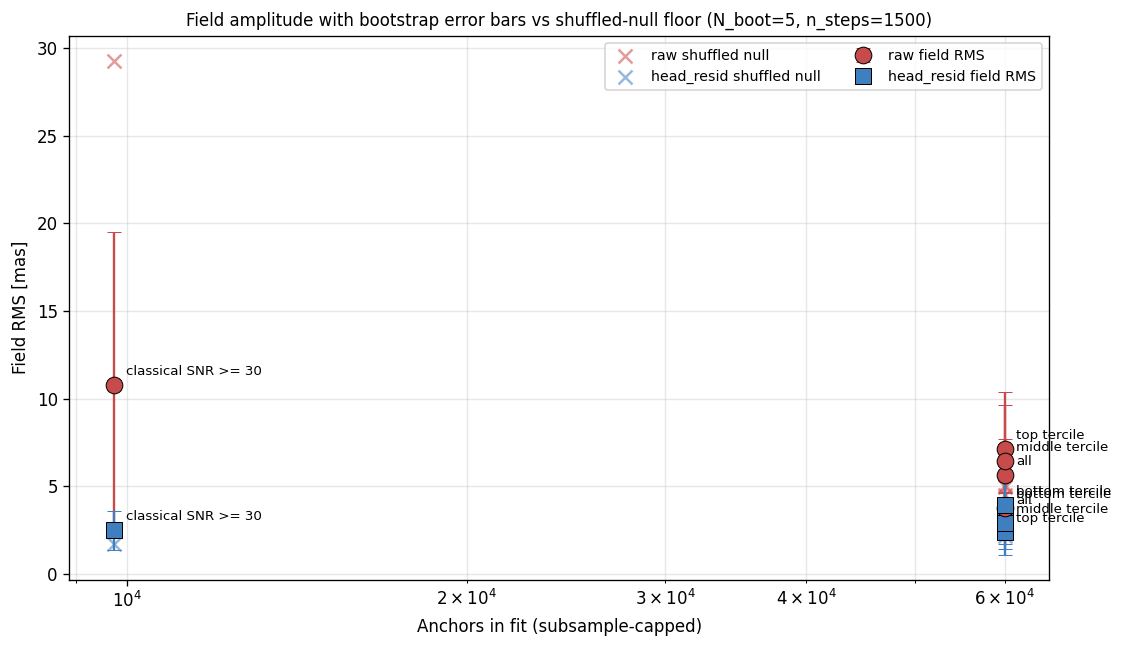


Signal/null ratios (median across slices):
         raw  signal/null  min=0.4×  med=1.3×  max=1.6×
  head_resid  signal/null  min=0.9×  med=1.4×  max=1.6×

Interpretation:
  - real >> null  : the smooth field is a genuine spatial signal in this slice/kind.
  - real ≈ null   : the PINN is fitting noise; the apparent field is not trustworthy.
  - The head_resid columns should sit close to zero AND close to the null -- the head
    has already removed the coherent component, so there is little smooth field left to fit.


In [18]:
# Plot: bootstrap field RMS vs shuffled-null floor, by anchor pool and kind.
# Squares = head_resid kind, circles = raw kind. X-axis = anchors used in fit (subsample-capped).
# Real-signal points carry vertical 1σ_boot bars; null points are crosses.
# A point well above its corresponding null cross = significant smooth-field detection at that slice.

fig, ax = plt.subplots(figsize=(9.5, 5.5))
kind_style = {"raw": ("o", "#c84b4b"), "head_resid": ("s", "#3f7fbf")}
seen_labels = set()
for r in trust_rows:
    marker, color = kind_style[r["kind"]]
    label_real = f"{r['kind']} field RMS"
    label_null = f"{r['kind']} shuffled null"
    ax.errorbar(
        [r["N_used"]], [r["rms_mean"]], yerr=[r["rms_std"]],
        fmt=marker, ms=10, color=color, ecolor=color, elinewidth=1.4, capsize=4,
        markeredgecolor="k", markeredgewidth=0.6,
        label=label_real if label_real not in seen_labels else None,
    )
    seen_labels.add(label_real)
    ax.scatter([r["N_used"]], [r["rms_null"]], marker="x", s=70, color=color, alpha=0.55,
               label=label_null if label_null not in seen_labels else None)
    seen_labels.add(label_null)
    ax.annotate(slice_label(r["slice"]), (r["N_used"], r["rms_mean"]),
                xytext=(7, 6), textcoords="offset points", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Anchors in fit (subsample-capped)", fontsize=10)
ax.set_ylabel("Field RMS [mas]", fontsize=10)
ax.set_title(f"Field amplitude with bootstrap error bars vs shuffled-null floor "
             f"(N_boot={N_BOOT}, n_steps={N_STEPS_FAST})", fontsize=10)
ax.legend(fontsize=8.5, loc="upper right", ncol=2)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(FIGS / "snr_field_amp_with_null.png", dpi=180, bbox_inches="tight")
plt.show()

# Compact significance summary, by kind. Tells you whether the real-data field beats the null.
print("\nSignal/null ratios (median across slices):")
for kind in KINDS:
    rows_k = [r for r in trust_rows if r["kind"] == kind]
    if not rows_k:
        continue
    sig = np.array([r["snr_significance"] for r in rows_k])
    print(f"  {kind:>10}  signal/null  min={sig.min():.1f}×  med={np.median(sig):.1f}×  max={sig.max():.1f}×")
print("\nInterpretation:")
print("  - real >> null  : the smooth field is a genuine spatial signal in this slice/kind.")
print("  - real ≈ null   : the PINN is fitting noise; the apparent field is not trustworthy.")
print("  - The head_resid columns should sit close to zero AND close to the null -- the head")
print("    has already removed the coherent component, so there is little smooth field left to fit.")


## Part 4c -- Gaussian Process cross-check on the smooth field

The PINN is one way to fit a smooth field; its uncertainty has to be estimated by bootstrap
because the smoothness is set by curl/Laplacian regulariser weights, not by an interpretable
kernel. A Gaussian Process with an explicit kernel (RBF + white noise) gives a calibrated
posterior and serves as a methodologically independent cross-check on the PINN field.
It is not an independent data set; it uses the same anchors with a different smooth-field model.

A pooled all-band GP would mix band-dependent structure, and a scalar-magnitude comparison
would miss vector-direction errors. This cell therefore does a **band-matched vector comparison**:

1. Selects one band from the **classical raw** slice (`SNR >= 30`; default `i`) and fits two
   separate scalar GPs on $\Delta\mathrm{RA}^*$ and $\Delta\mathrm{Dec}$.
2. Evaluates the PINN for the same band (`geometric + chromatic`) on the same mesh.
3. Compares the vector field with $\sqrt{(\Delta\mathrm{RA})^2 + (\Delta\mathrm{Dec})^2}$,
   not just the difference of magnitudes.
4. Holds out 20% of anchors for a calibration check.

The GP length scale is the data-preferred correlation length for this band/slice.


/home/shemmati/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/shemmati/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 15.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/shemmati/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/shemmati/.local/lib/python3.9/site-packages/sklearn/gaus

GP fits done in 1.2s on 1200 i anchors
  fit length scale (dRA, dDec): 15.0", 15.0"
GP mesh predict (146,102 pts) done in 8.8s


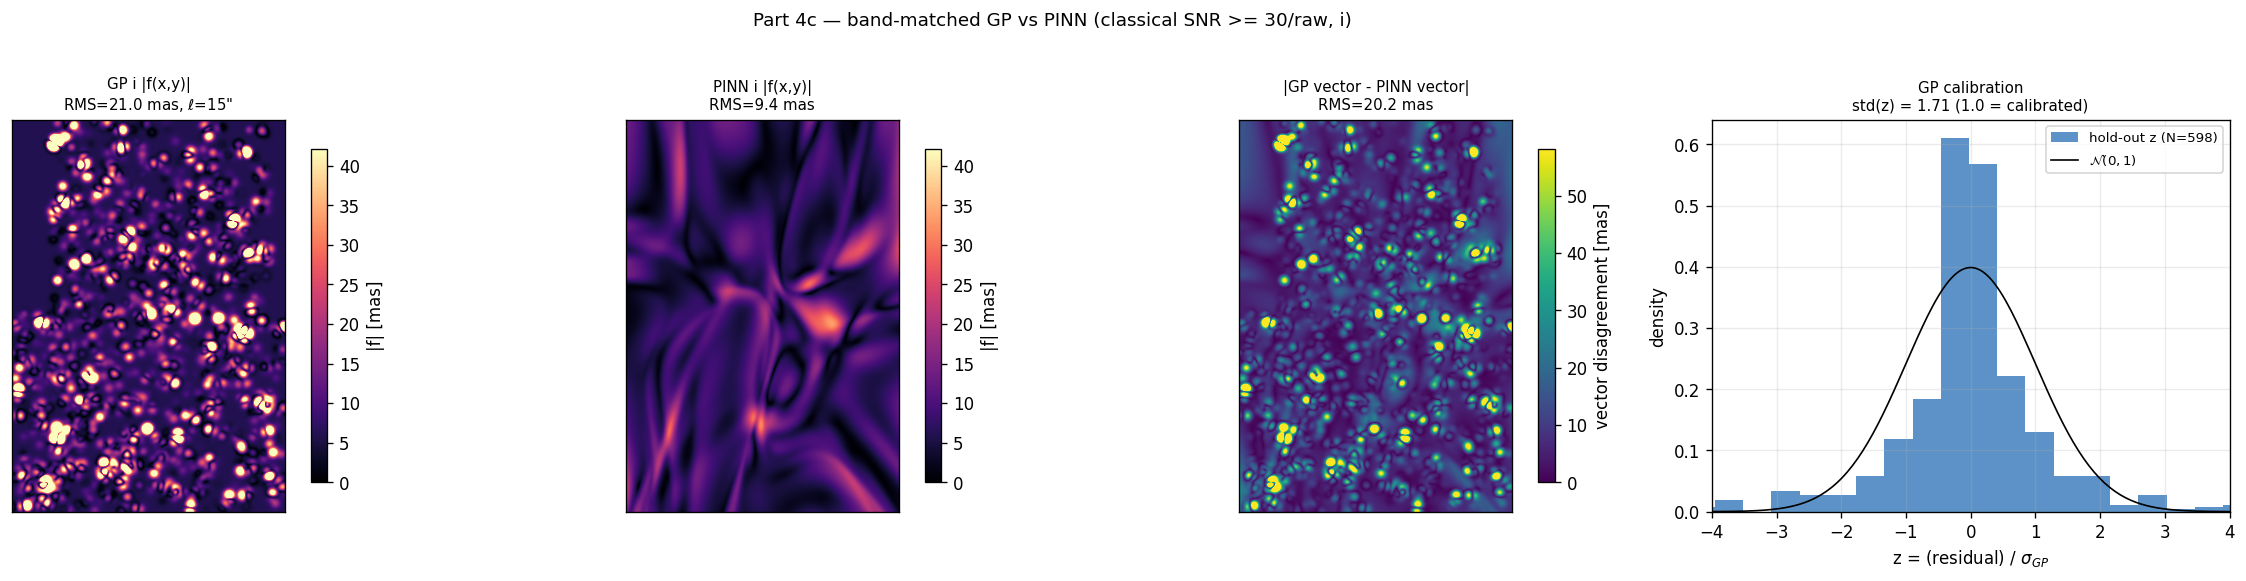


Cross-check summary:
  Band / slice          : i / classical SNR >= 30 raw
  GP field RMS          : 20.99 mas
  PINN field RMS        : 9.39 mas
  vector diff RMS       : 20.24 mas
    dRA component RMS   : 14.17 mas
    dDec component RMS  : 14.45 mas
  GP fit length scale   : 15.0" (dRA), 15.0" (dDec)
  GP calibration std(z) : 1.71  (target 1.0)


In [19]:
# === Part 4c: GP cross-check on a band-matched classical/raw slice ===
# Independent smooth-field measurement using a Gaussian Process with an interpretable kernel.
# The comparison is vector-valued: |GP_vector - PINN_vector|, not GP |f| - PINN |f|.

try:
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import ConstantKernel as _C, RBF, WhiteKernel
    _HAVE_SK = True
except ImportError:
    _HAVE_SK = False
    print("sklearn not available; skipping GP cross-check")

if _HAVE_SK:
    import time as _time

    GP_SLICE, GP_KIND = "classical", "raw"
    GP_BAND = "i" if "i" in bands_present else bands_present[0]
    N_GP = int(_os.environ.get("NB07_GP_N", "1500"))
    MESH_STRIDE = int(_os.environ.get("NB07_GP_MESH_STRIDE", "4"))
    HOLDOUT_FRAC = 0.20

    if (GP_SLICE, GP_KIND) not in fits_store:
        print(f"PINN fit for {slice_label(GP_SLICE)}/{GP_KIND} not in fits_store -- run Part 4 first")
    else:
        tab_all = build_slice(GP_SLICE, GP_KIND)
        band_code = BAND_TO_IDX[GP_BAND]
        mask_band = tab_all["band_idx"] == band_code
        if mask_band.sum() < 100:
            raise RuntimeError(f"Not enough {display_band(GP_BAND)} anchors for GP check: {mask_band.sum()}")

        pos_band = tab_all["pos"][mask_band].astype(np.float64)
        off_band = tab_all["offsets"][mask_band].astype(np.float64)

        rng = np.random.default_rng(42)
        idx_sub = rng.choice(len(pos_band), size=min(N_GP, len(pos_band)), replace=False)
        pos_sub = pos_band[idx_sub]
        off_sub = off_band[idx_sub]

        # Hold-out split for calibration.
        n_hold = max(1, int(HOLDOUT_FRAC * len(idx_sub)))
        hold_mask = np.zeros(len(idx_sub), dtype=bool)
        hold_mask[rng.choice(len(idx_sub), size=n_hold, replace=False)] = True
        fit_mask = ~hold_mask

        # Kernel: learnable-amplitude RBF + white noise. Bounds prevent degenerate solutions.
        kernel = (
            _C(1e-3, (1e-7, 1.0)) * RBF(length_scale=60.0, length_scale_bounds=(15.0, 400.0))
            + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 1e-2))
        )

        gp_dra  = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True,
                                           n_restarts_optimizer=2, random_state=0)
        gp_ddec = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True,
                                           n_restarts_optimizer=2, random_state=1)

        t0 = _time.time()
        gp_dra.fit(pos_sub[fit_mask], off_sub[fit_mask, 0])
        gp_ddec.fit(pos_sub[fit_mask], off_sub[fit_mask, 1])
        print(f"GP fits done in {_time.time()-t0:.1f}s on {int(fit_mask.sum())} {display_band(GP_BAND)} anchors")

        def _rbf_length(k):
            try:
                return float(k.k1.k2.length_scale)
            except Exception:
                for sub in getattr(k, "k1", k), getattr(k, "k2", None):
                    if sub is not None and hasattr(sub, "length_scale"):
                        return float(sub.length_scale)
                return float("nan")

        ell_dra  = _rbf_length(gp_dra.kernel_)
        ell_ddec = _rbf_length(gp_ddec.kernel_)
        print(f'  fit length scale (dRA, dDec): {ell_dra:.1f}", {ell_ddec:.1f}"')

        # Mesh prediction at stride for speed.
        ny, nx = FIELD_H, FIELD_W
        ys = np.arange(0, ny, MESH_STRIDE)
        xs = np.arange(0, nx, MESH_STRIDE)
        yy_g, xx_g = np.meshgrid(ys, xs, indexing="ij")
        mesh_xy = np.stack([xx_g.ravel(), yy_g.ravel()], axis=1).astype(np.float64)
        t0 = _time.time()
        mean_dra,  std_dra  = gp_dra.predict(mesh_xy,  return_std=True)
        mean_ddec, std_ddec = gp_ddec.predict(mesh_xy, return_std=True)
        print(f"GP mesh predict ({mesh_xy.shape[0]:,} pts) done in {_time.time()-t0:.1f}s")

        gp_dra_map  = (mean_dra  * 1000.0).reshape(yy_g.shape)
        gp_ddec_map = (mean_ddec * 1000.0).reshape(yy_g.shape)
        gp_mag_map  = np.hypot(gp_dra_map, gp_ddec_map)
        gp_field_rms = float(np.sqrt(np.nanmean(gp_dra_map ** 2 + gp_ddec_map ** 2)))

        # PINN field for the same band: geometric + chromatic, evaluated on the same stride mesh.
        pinn_entry = fits_store[(GP_SLICE, GP_KIND)]
        pinn_band = evaluate_pinn_mesh(
            pinn_entry["model"], pinn_entry["meta"], FIELD_H, FIELD_W,
            dstep=MESH_STRIDE, band_idx=band_code,
        )
        pinn_dra_map  = pinn_band["dra"] * 1000.0
        pinn_ddec_map = pinn_band["ddec"] * 1000.0
        pinn_mag_map  = np.hypot(pinn_dra_map, pinn_ddec_map)
        pinn_field_rms = float(np.sqrt(np.nanmean(pinn_dra_map ** 2 + pinn_ddec_map ** 2)))

        # Crop to common shape (in case stride does not divide evenly).
        H_min = min(gp_mag_map.shape[0], pinn_mag_map.shape[0])
        W_min = min(gp_mag_map.shape[1], pinn_mag_map.shape[1])
        gp_dra_c, gp_ddec_c = gp_dra_map[:H_min, :W_min], gp_ddec_map[:H_min, :W_min]
        pinn_dra_c, pinn_ddec_c = pinn_dra_map[:H_min, :W_min], pinn_ddec_map[:H_min, :W_min]
        gp_mag_c = gp_mag_map[:H_min, :W_min]
        pinn_mag_c = pinn_mag_map[:H_min, :W_min]
        vec_diff = np.hypot(gp_dra_c - pinn_dra_c, gp_ddec_c - pinn_ddec_c)
        vec_diff_rms = float(np.sqrt(np.nanmean(vec_diff ** 2)))
        dra_diff_rms = float(np.sqrt(np.nanmean((gp_dra_c - pinn_dra_c) ** 2)))
        ddec_diff_rms = float(np.sqrt(np.nanmean((gp_ddec_c - pinn_ddec_c) ** 2)))

        # Calibration check: held-out component z-scores.
        h_dra,  h_std_dra  = gp_dra.predict(pos_sub[hold_mask],  return_std=True)
        h_ddec, h_std_ddec = gp_ddec.predict(pos_sub[hold_mask], return_std=True)
        z_dra  = (off_sub[hold_mask, 0] - h_dra)  / np.maximum(h_std_dra,  1e-9)
        z_ddec = (off_sub[hold_mask, 1] - h_ddec) / np.maximum(h_std_ddec, 1e-9)
        zscore = np.concatenate([z_dra, z_ddec])
        z_clip = zscore[np.abs(zscore) < 10]
        z_std = float(np.std(z_clip))

        fig, axes = plt.subplots(1, 4, figsize=(20, 4.7))
        vmax_field = max(10.0, float(np.nanpercentile(np.concatenate([gp_mag_c.ravel(), pinn_mag_c.ravel()]), 98)))
        vmax_diff = max(3.0, float(np.nanpercentile(vec_diff.ravel(), 98)))
        ext_mesh = [0, W_min * MESH_STRIDE, 0, H_min * MESH_STRIDE]

        ax = axes[0]
        im = ax.imshow(gp_mag_c, cmap="magma", vmin=0, vmax=vmax_field, origin="lower",
                       extent=ext_mesh, aspect="equal")
        ax.set_title(f'GP {display_band(GP_BAND)} |f(x,y)|\nRMS={gp_field_rms:.1f} mas, $\\ell$={ell_dra:.0f}"', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, label="|f| [mas]", shrink=0.85)

        ax = axes[1]
        im = ax.imshow(pinn_mag_c, cmap="magma", vmin=0, vmax=vmax_field, origin="lower",
                       extent=ext_mesh, aspect="equal")
        ax.set_title(f"PINN {display_band(GP_BAND)} |f(x,y)|\nRMS={pinn_field_rms:.1f} mas", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, label="|f| [mas]", shrink=0.85)

        ax = axes[2]
        im = ax.imshow(vec_diff, cmap="viridis", vmin=0, vmax=vmax_diff, origin="lower",
                       extent=ext_mesh, aspect="equal")
        ax.set_title(f"|GP vector - PINN vector|\nRMS={vec_diff_rms:.1f} mas", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, label="vector disagreement [mas]", shrink=0.85)

        ax = axes[3]
        ax.hist(z_clip, bins=40, color="#3f7fbf", alpha=0.85, density=True,
                label=f"hold-out z (N={len(z_clip)})")
        zz = np.linspace(-4, 4, 200)
        ax.plot(zz, np.exp(-zz ** 2 / 2) / np.sqrt(2 * np.pi), "k-", lw=1, label=r"$\mathcal{N}(0,1)$")
        ax.set_xlim(-4, 4)
        ax.set_xlabel("z = (residual) / $\sigma_{GP}$")
        ax.set_ylabel("density")
        ax.set_title(f"GP calibration\nstd(z) = {z_std:.2f} (1.0 = calibrated)", fontsize=9)
        ax.legend(fontsize=8); ax.grid(alpha=0.25)

        plt.suptitle(f"Part 4c — band-matched GP vs PINN ({slice_label(GP_SLICE)}/{GP_KIND}, {display_band(GP_BAND)})",
                     fontsize=11, y=1.02)
        plt.tight_layout()
        plt.savefig(FIGS / "gp_vs_pinn_field.png", dpi=180, bbox_inches="tight")
        plt.show()

        print("\nCross-check summary:")
        print(f"  Band / slice          : {display_band(GP_BAND)} / {slice_label(GP_SLICE)} {GP_KIND}")
        print(f"  GP field RMS          : {gp_field_rms:.2f} mas")
        print(f"  PINN field RMS        : {pinn_field_rms:.2f} mas")
        print(f"  vector diff RMS       : {vec_diff_rms:.2f} mas")
        print(f"    dRA component RMS   : {dra_diff_rms:.2f} mas")
        print(f"    dDec component RMS  : {ddec_diff_rms:.2f} mas")
        print(f'  GP fit length scale   : {ell_dra:.1f}" (dRA), {ell_ddec:.1f}" (dDec)')
        print(f"  GP calibration std(z) : {z_std:.2f}  (target 1.0)")


## Part 5 -- Sparse-field recovery

The sparse-field question in pictures.

- **Geometric field maps** for the classical `SNR >= 30` raw fit, the faint raw fit and the
  all-raw fit, plus the corresponding head-residual fits. If the head absorbs the coherent
  field, the head-residual maps should be small and close to their null floors.
- **Field amplitude vs anchor count** shows whether removing or adding anchor pools changes
  the fitted smooth-field amplitude.
- **Head-implied field.** `head_pred = raw - head_resid` is what the head predicts per source.
  This is algebraically derived from raw and head-residual offsets, so it is descriptive, not
  independent proof by itself. The stronger sparse-field check below fits `head_pred` only on
  non-classical sources (`SNR < 30`) and compares that field to the separate classical raw
  `SNR >= 30` fit.


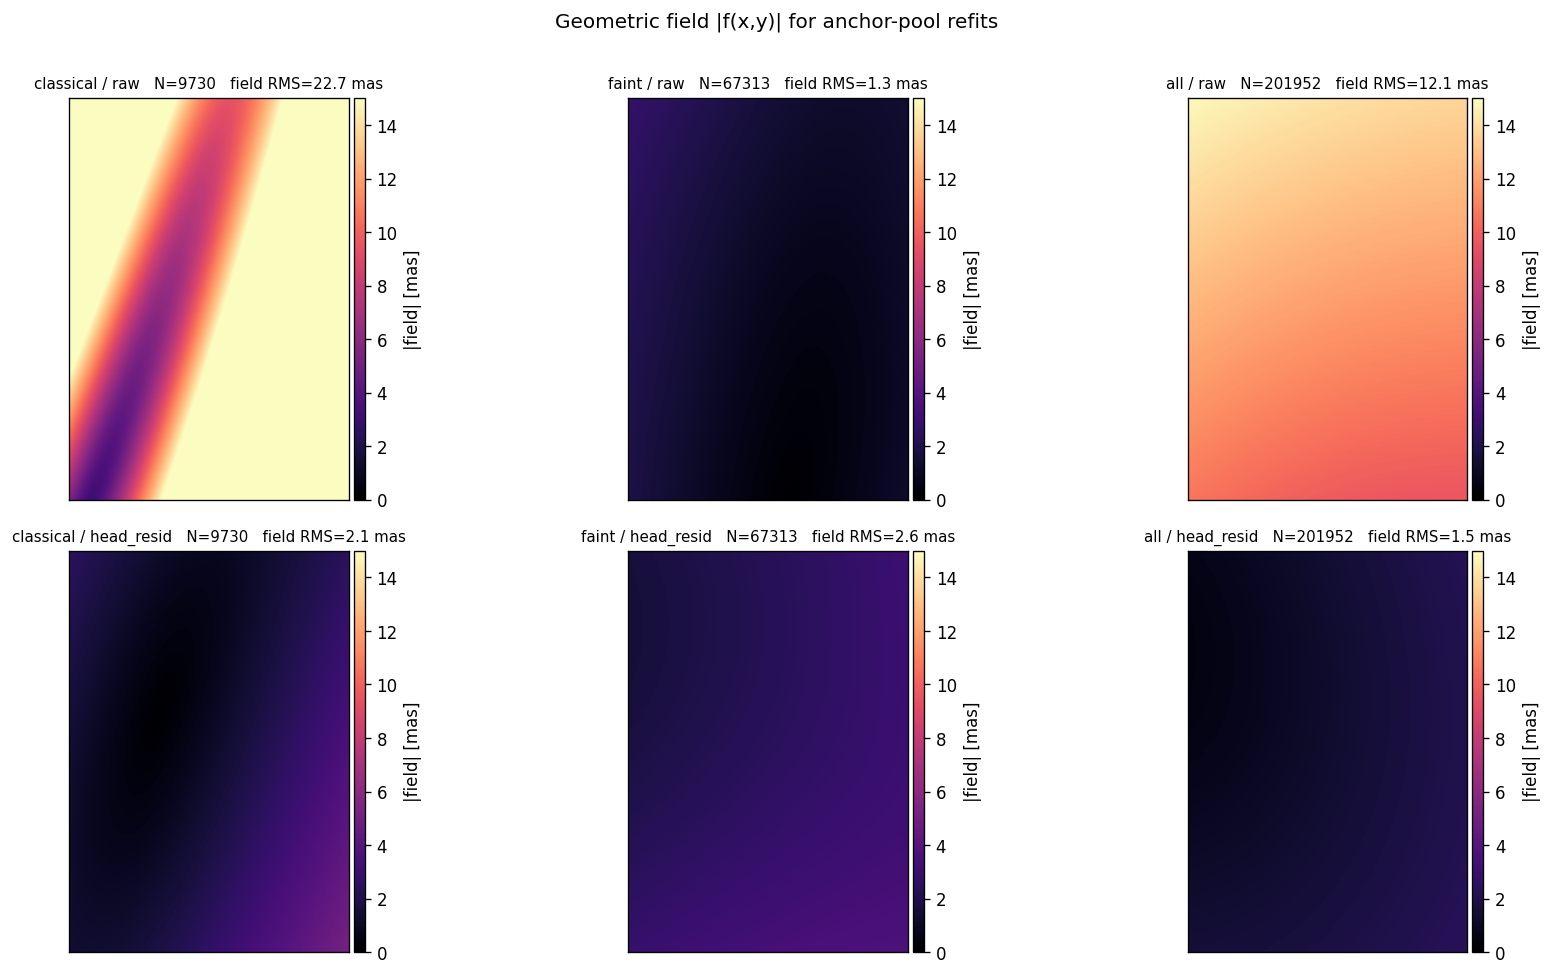

In [ ]:
# Side-by-side geometric field maps.
PANELS = [
    ("classical / raw", ("classical", "raw")),
    ("faint / raw",  ("faint",  "raw")),
    ("all / raw",    ("all",    "raw")),
    ("classical / head_resid", ("classical", "head_resid")),
    ("faint / head_resid",  ("faint",  "head_resid")),
    ("all / head_resid",    ("all",    "head_resid")),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
vmax_map = 15.0
for ax, (label, key) in zip(axes.ravel(), PANELS):
    if key not in fits_store:
        ax.axis("off"); continue
    geo = fits_store[key]["geo"]
    mag = np.hypot(geo["dra"], geo["ddec"]) * 1000.0
    im = ax.imshow(mag, cmap="magma", vmin=0, vmax=vmax_map, origin="lower",
                   extent=[0, FIELD_W, 0, FIELD_H], aspect="equal")
    n = fits_store[key]["table"]["pos"].shape[0]
    rms = np.sqrt(np.nanmean((geo["dra"] * 1000) ** 2 + (geo["ddec"] * 1000) ** 2))
    ax.set_title(f"{label}   N={n}   field RMS={rms:.1f} mas", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.04)
    plt.colorbar(im, cax=cax, label="|field| [mas]")
plt.suptitle("Geometric field |f(x,y)| for anchor-pool refits", y=1.01)
plt.tight_layout()
plt.show()


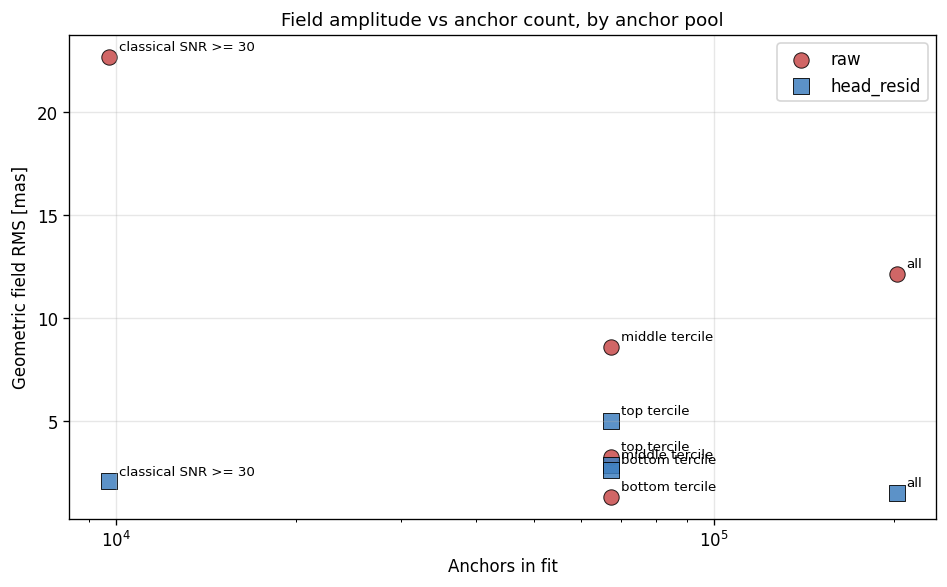

In [21]:
# Field amplitude vs anchor count summary plot.
fig, ax = plt.subplots(figsize=(8, 5))
kind_style = {"raw": ("o", "#c84b4b"), "head_resid": ("s", "#3f7fbf")}
for (snr_mode, kind), entry in fits_store.items():
    n = entry["table"]["pos"].shape[0]
    rms = np.sqrt(np.nanmean(
        (entry["geo"]["dra"] * 1000) ** 2 + (entry["geo"]["ddec"] * 1000) ** 2
    ))
    marker, color = kind_style[kind]
    ax.scatter(n, rms, marker=marker, s=85, color=color, alpha=0.85, edgecolor="k", linewidth=0.6,
               label=f"{kind}" if snr_mode == "bright" else None)
    ax.annotate(slice_label(snr_mode), (n, rms), xytext=(6, 4), textcoords="offset points", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Anchors in fit", fontsize=10)
ax.set_ylabel("Geometric field RMS [mas]", fontsize=10)
ax.set_title("Field amplitude vs anchor count, by anchor pool", fontsize=11)
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


head_pred non-classical anchor pool (SNR < 30): 192222
  per-band: u=6,765, g=18,555, r=20,504, i=18,426, z=14,028, y=7,227, NISP Y=33,147, NISP J=37,368, NISP H=36,202
head_pred non-classical PINN fit: 158.8s  best_loss=0.1629
head-implied non-classical field RMS: 4.8 mas
head-implied(non-classical) vs classical/raw vector RMS: 23.98 mas
  median vector disagreement: 17.84 mas


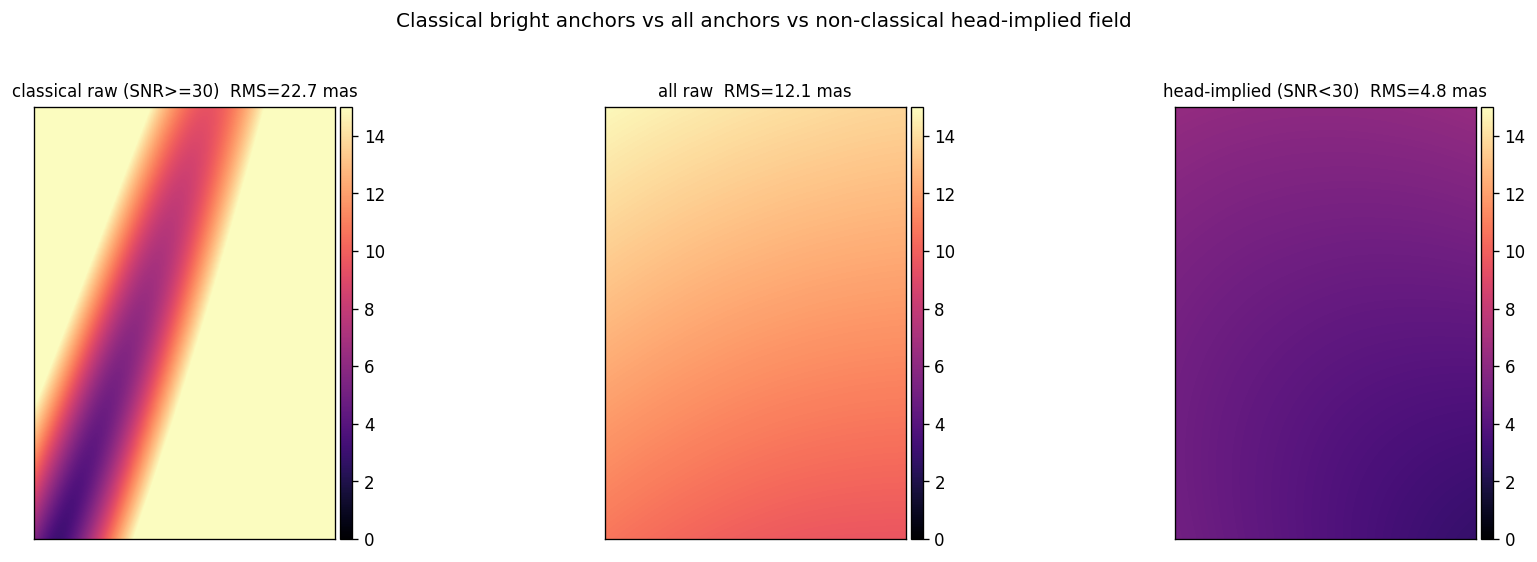

In [22]:
# Head-implied field: fit a PINN to head_pred = raw - head_resid using non-classical anchors.
#
# Because head_pred is algebraically derived from raw and head_resid, the meaningful sparse-field
# check is source-disjoint: fit head_pred only on SNR < 30 anchors, then compare the resulting smooth
# field to the classical SNR >= 30 raw fit.

pos_hp = []
off_hp = []
bi_hp = []
w_hp = []
n_hp_per_band = {}
for band in bands_present:
    d = data[band]
    snr = d["snr"]
    good = np.isfinite(snr) & (snr > 0) & (snr < SNR_CLASSICAL)
    if good.sum() < 30:
        continue
    pos_hp.append(tangent_shifted(d["ra"][good], d["dec"][good]))
    off_hp.append(d["head_pred"][good])
    bi_hp.append(np.full(int(good.sum()), BAND_TO_IDX[band], dtype=np.int64))
    w_hp.append(snr_weights_for_band(band, snr[good]))
    n_hp_per_band[band] = int(good.sum())

if not pos_hp:
    raise RuntimeError("No non-classical anchors available for head-implied sparse-field test")

pos_hp = np.concatenate(pos_hp)
off_hp = np.concatenate(off_hp).astype(np.float32)
bi_hp = np.concatenate(bi_hp)
w_hp = np.concatenate(w_hp)
print(f"head_pred non-classical anchor pool (SNR < {SNR_CLASSICAL:.0f}): {len(pos_hp)}")
print("  per-band: " + ", ".join(f"{display_band(b)}={n:,}" for b, n in n_hp_per_band.items()))

t0 = time.time()
model_hp, meta_hp = fit_pinn_field(
    pos_arcsec=pos_hp, offsets_arcsec=off_hp, weights=w_hp,
    band_indices=bi_hp, n_bands=N_BANDS,
    n_steps=N_STEPS_REFIT, n_collocation=N_COLLOC_REFIT,
    device=DEVICE, verbose=False,
)
print(f"head_pred non-classical PINN fit: {time.time() - t0:.1f}s  best_loss={meta_hp['best_loss']:.4g}")
geo_hp = evaluate_pinn_mesh(model_hp, meta_hp, FIELD_H, FIELD_W, dstep=1, band_idx=None)
rms_hp = float(np.sqrt(np.nanmean((geo_hp["dra"] * 1000) ** 2 + (geo_hp["ddec"] * 1000) ** 2)))
print(f"head-implied non-classical field RMS: {rms_hp:.1f} mas")

# Compare side by side: classical raw, all raw, and non-classical head-implied.
classical_geo = fits_store.get(("classical", "raw"), {}).get("geo")
all_raw_geo = fits_store.get(("all", "raw"), {}).get("geo")

if classical_geo is not None:
    vec_delta = np.hypot(
        (geo_hp["dra"] - classical_geo["dra"]) * 1000.0,
        (geo_hp["ddec"] - classical_geo["ddec"]) * 1000.0,
    )
    print(f"head-implied(non-classical) vs classical/raw vector RMS: "
          f"{float(np.sqrt(np.nanmean(vec_delta ** 2))):.2f} mas")
    print(f"  median vector disagreement: {float(np.nanmedian(vec_delta)):.2f} mas")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
panels_hp = [
    (f"classical raw (SNR>={SNR_CLASSICAL:.0f})", classical_geo),
    ("all raw", all_raw_geo),
    (f"head-implied (SNR<{SNR_CLASSICAL:.0f})", geo_hp),
]
for ax, (label, geo) in zip(axes, panels_hp):
    if geo is None:
        ax.axis("off"); continue
    mag = np.hypot(geo["dra"], geo["ddec"]) * 1000.0
    im = ax.imshow(mag, cmap="magma", vmin=0, vmax=15, origin="lower",
                   extent=[0, FIELD_W, 0, FIELD_H], aspect="equal")
    rms = float(np.sqrt(np.nanmean((geo["dra"] * 1000) ** 2 + (geo["ddec"] * 1000) ** 2)))
    ax.set_title(f"{label}  RMS={rms:.1f} mas", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.04)
    plt.colorbar(im, cax=cax)
plt.suptitle("Classical bright anchors vs all anchors vs non-classical head-implied field", y=1.03)
plt.tight_layout()
plt.savefig(FIGS / "head_implied_vs_classical_field.png", dpi=180, bbox_inches="tight")
plt.show()


## Reading The Result

The four questions the notebook is built to answer, with the figure that answers each:

**1. How much do we increase the anchors?**
Part 3b, *anchor leverage* figure. We bin anchors on a 1 arcmin × 1 arcmin grid -- the same
60" scale used by the concordance field maps -- and compare the median per-cell density at
the classical (`SNR >= 30`) and head-enabled (all finite positive SNR) thresholds. The right
panel shows cell-coverage curves. Per-tile counts are useful operationally, but the fit's
leverage scales with anchors per resolution element, not per tile.

**2. Why use `SNR >= 30` for the classical cut?**
It is a practical high-SNR centroiding threshold, not a universal standard. For FWHM around
0.7 arcsec, `FWHM / (2.35 * SNR)` is about 10 mas at SNR 30 before systematic floors.
That makes `SNR >= 30` a reasonable classical baseline, but the notebook should be rerun
with stricter cuts such as `SNR >= 50` or `SNR >= 100` if the result hinges on this choice.

**3. How should we fit to use more anchors?**
Part 4 sets the recipe: a PINN field with three physics-informed regularisers
(curl-free for a true astrometric distortion, Laplacian smoothness, band-consistency),
fit jointly across all 9 non-VIS bands with a chromatic embedding. The weights are capped
and band-normalized SNR² weights, which preserve the `variance ∝ SNR^-2` intuition inside
each band without assuming Rubin and NISP SNR values share one absolute noise scale.

**4. How much residual-scatter reduction are we getting?**
Part 3b, *per-source residual scatter* figure. MADxy(raw) vs MADxy(head) gives the empirical
per-band scatter improvement factor. This is not a pure centroid-noise floor: it may include
training leakage, blending and unmodelled systematics. The SNR panel shows that classical raw
offsets roughly follow the expected `1/SNR` trend, while the head residual is much flatter.

**5. How much do we trust the fit, or are we just seeing noise?**
Two complementary parts:

*Part 4b — bootstrap + shuffled-null.* Bootstrap σ on field RMS quantifies sampling
uncertainty. The bootstrap is stratified by band, and the shuffled-null permutes positions
within each band so the footprint and band noise distribution are preserved. If σ_boot is
≪ field RMS and real/null is large, the fit is well-determined. If real/null is near one,
the apparent field is not trustworthy.

*Part 4c — Gaussian Process cross-check.* The GP comparison is band-matched and vectorial:
it compares `GP_vector - PINN_vector`, not just `|GP| - |PINN|`. Agreement to within a few mas
means the spatial pattern is robust across methods for that band/slice. The held-out z-score
histogram checks whether the GP posterior uncertainty is calibrated.

**Putting it together — the case for head-enabled concordance.** The strongest sparse-field
claim is not that `head_pred = raw - head_resid` looks like the raw field -- that is partly
algebraic. The stronger test is Part 5: fit the head-implied field using only non-classical
anchors (`SNR < 30`) and compare it to the separate classical raw field (`SNR >= 30`). If the
vector disagreement is only a few mas and the bootstrap/null diagnostics support the raw field,
then the head is turning the faint/mid source population into a useful dense sampling of the
concordance field.
